<a href="https://colab.research.google.com/github/ky106031/kaggle-study/blob/main/Spaceship_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# コンペ概要  
### ・西暦2912年、宇宙船「Spaceship Titanic」は13,000人もの乗客を乗せて移住先の惑星へ向かう途中、時空の異常と遭遇.
### ・その結果、乗客のほぼ半数が別次元へ転送.
### ・提供されたのは、損傷したコンピュータから回収された乗客の記録データ.
### ・のデータを使って誰が異次元へ「Transported」されたかを予測.
  
### ・タスク：乗客が異次元に「Transported」されたかどうか（True／False）の予測.
### ・評価指標：Accuracy（正解率）

# 🚀 Spaceship Titanic: A complete guide 🏆

https://www.kaggle.com/code/samuelcortinhas/spaceship-titanic-a-complete-guide

In [ ]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.1 MB/s eta 0:00:00


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00


In [ ]:
from io import IncrementalNewlineDecoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
from imblearn.over_sampling import SMOTE
import itertools
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.utils import resample

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
url_train = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/spaceship-titanic/train.csv'
url_test = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/spaceship-titanic/test.csv'
train = pd.read_csv(url_train)
test = pd.read_csv(url_test)

In [ ]:
print('Train set shape {}'.format(train.shape))
print('Test set shape {}'.format(test.shape))
train.head()

Train set shape (8693, 14)
Test set shape (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# PassengerId
# :・各乗客ごとに一意のID。形式は gggg_pp。
# ・gggg はその乗客が一緒に旅行しているグループを示す
# ・pp はグループ内での番号

# HomePlanet
# : 乗客が出発した惑星。通常はその人の恒久的な居住惑星。

# CryoSleep
# ・乗客が航海中に「人工冬眠（休眠状態）」を選択したかどうかを示す。
# ・人工冬眠中の乗客は客室に閉じ込められている

# Cabin
# ・乗客が滞在しているキャビン番号。形式は deck/num/side
# ・deck：デッキ階（客船の階層） → 縦の位置
# ・num：キャビン番号（ホテルでいう部屋番号） → 前後の位置
# ・side：P は Port（左舷）、S は Starboard（右舷） → 左右の位置

# Destination
# ・乗客が降り立つ予定の惑星

# Age
# ・乗客の年齢。

# VIP
# ・航海中に特別な VIP サービスを利用したかどうか。

# RoomService, FoodCourt, ShoppingMall, Spa, VRDeck
# ・乗客が Spaceship Titanic 内の各種高級設備で利用した金額

# Name
# ・乗客の名前（名と姓）。

# Transported
# ・乗客が別の次元に転送されたかどうかを示す
# ・これが 目的変数（予測対象）

In [ ]:
print('TRAIN SET MISSING VALUES:')
print(train.isnull().sum())
print('')
print('TEST SET MISSING VALUES:')
print(test.isnull().sum())

TRAIN SET MISSING VALUES:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

TEST SET MISSING VALUES:
PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


In [ ]:
# Duplicates

print(f'Duplicates in train set: {train.duplicated().sum()}, ({np.round(100*train.duplicated().sum()/len(train),1)}%)')
print('')
print(f'Duplicates in test set: {test.duplicated().sum()}, ({np.round(100*test.duplicated().sum()/len(test),1)})%')

# <重複行がどれくらいかるかの確認>
# ・重複があるとモデルがバイアスを持つ可能性があるため、EDAの一環としてよく実行する

# <なぜデータの重複をチェックするのか>
# ・モデルのバイアスを防ぐため
# 　→ 同じ行が繰り返し学習データにあると、そのサンプルの影響が課題になる
# ・データの収集過程の不備を発見できる
# 　→kaggleコンペのデータは綺麗なことが多いが、実務では重複が頻繁に混ざる
# ・EDAの一環として自然
# 　→欠損値チェック、データ型チェックと同じく「作法」として確認するのが良い

# <必ずやるべきケース>
# ・実務のデータ分析（センサーやログなどは重複しやすいので必須）
# ・サンプル数が少ない場合（重複が数件あるだけで全体に影響しやすい）

Duplicates in train set: 0, (0.0%)

Duplicates in test set: 0, (0.0)%


In [ ]:
# Cardinality of features
# Cardinality : データ分析やデータベース分野で使われる用語。「ある特徴量（列）が取りうるユニークな値の数」

# .unique() → Series専用。ユニークな値そのものを返す。
# .nunique() → SeriesでもDataFrameでもOK。ユニークな値の「数」を返す。

train.nunique()

,0
PassengerId,8693
HomePlanet,3
CryoSleep,2
Cabin,6560
Destination,3
Age,80
VIP,2
RoomService,1273
FoodCourt,1507
ShoppingMall,1115


In [ ]:
# Data types
train.dtypes

,0
PassengerId,object
HomePlanet,object
CryoSleep,object
Cabin,object
Destination,object
Age,float64
VIP,object
RoomService,float64
FoodCourt,float64
ShoppingMall,float64


In [ ]:
# EDA

Text(0.5, 1.0, 'Target distribution')

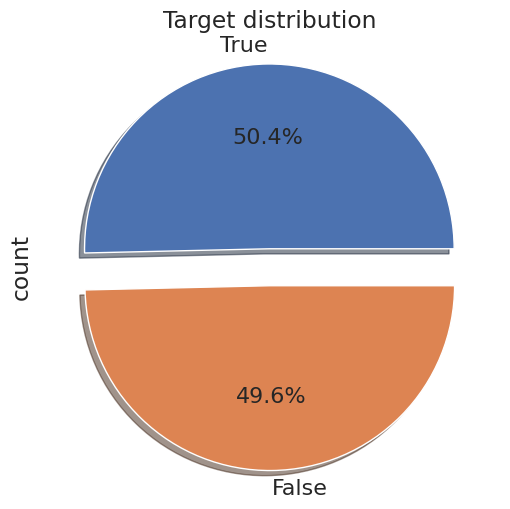

In [ ]:
# Target distribution

plt.figure(figsize=(6,6))

# pie plot
train['Transported'].value_counts().plot.pie(
    explode=[0.1,0.1],
    autopct='%1.1f%%',
    shadow=True,
    textprops={'fontsize':16}
).set_title('Target distribution')

Text(0.5, 0, 'Age(yeas)')

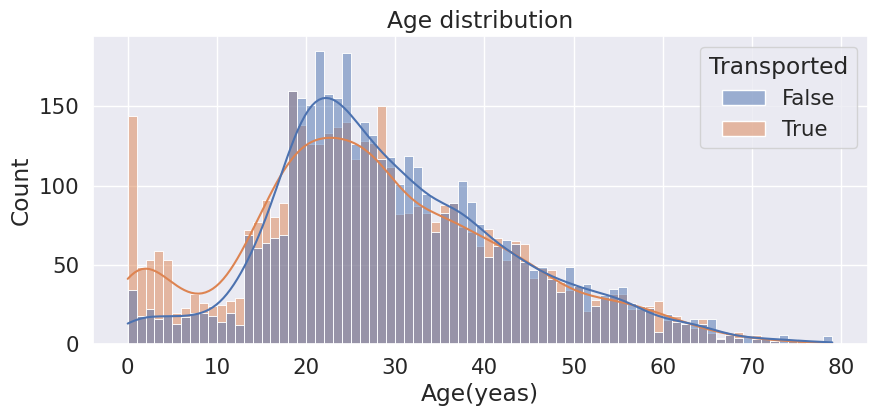

In [ ]:
# Continuous features

plt.figure(figsize=(10,4))

sns.histplot(
    data=train,
    x='Age',
    hue='Transported',
    binwidth=1,
    kde=True     # KDE（確率密度曲線）を重ねて描画
)

plt.title('Age distribution')
plt.xlabel('Age(yeas)')

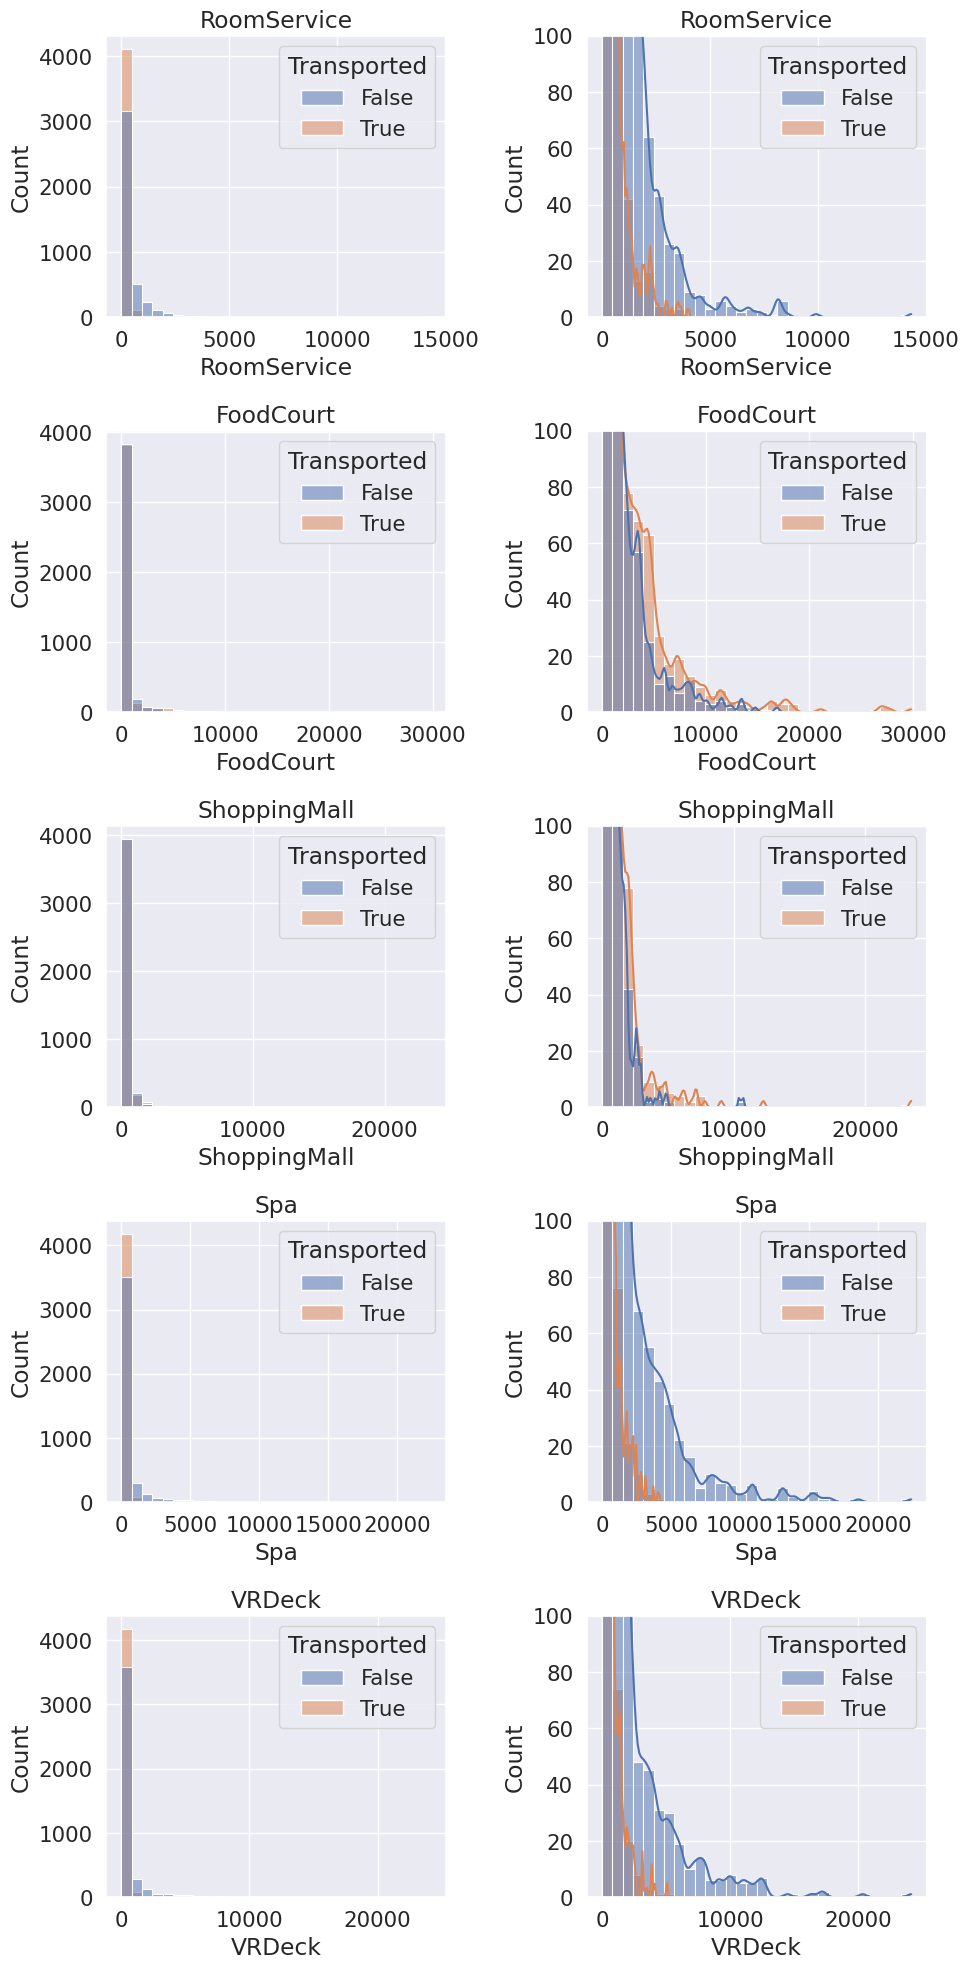

In [ ]:
# Expenditure features
exp_feats = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig = plt.figure(figsize=(10,20))
for i, var_name in enumerate(exp_feats):
  # left plot
  ax = fig.add_subplot(5,2,2*i+1)
  sns.histplot(
      data=train,
      x=var_name,
      axes=ax,
      bins=30,
      kde=False,
      hue='Transported')
  ax.set_title(var_name)

  ax = fig.add_subplot(5,2,2*i+2)
  sns.histplot(
      data=train,
      x=var_name,
      axes=ax,
      bins=30,
      kde=True,
      hue='Transported'
  )
  plt.ylim([0, 100])
  ax.set_title(var_name)

fig.tight_layout()
plt.show()

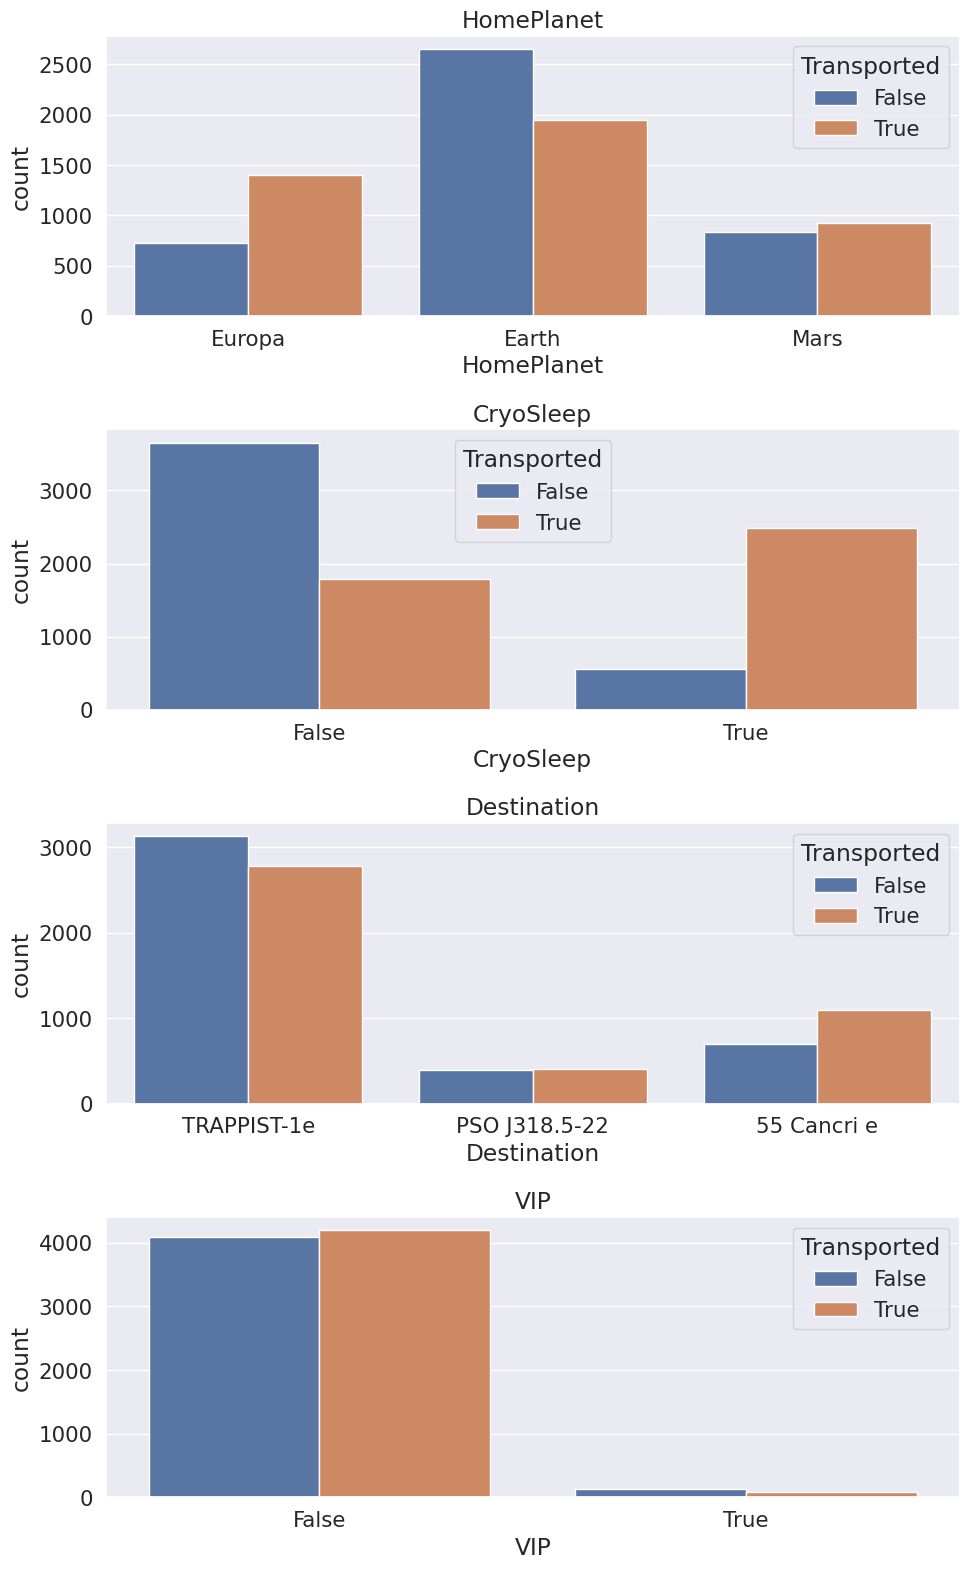

In [ ]:
# Categorical features
cat_feats = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig = plt.figure(figsize=(10,16))
for i, var_name in enumerate(cat_feats):
  ax=fig.add_subplot(4,1,i+1)
  sns.countplot(
      data=train,
      x=var_name,
      axes=ax,
      hue='Transported'
  )
  ax.set_title(var_name)

fig.tight_layout()
plt.show()

# countplot
# ・件数（サンプル数）の分布を可視化
# ・y : サンプル数（カウント）
# ・引数 ：x のみでOK

# barplot
# ・数値変数の統計量（平均など）をカテゴリ別に可視化
# ・y : 数値（平均、合計、中央値など）
# ・x（カテゴリ）, y（数値）が必要

In [ ]:
qual_feats = ['PassengerId', 'Cabin' ,'Name']
train[qual_feats].head()

,PassengerId,Cabin,Name
0,0001_01,B/0/P,Maham Ofracculy
1,0002_01,F/0/S,Juanna Vines
2,0003_01,A/0/S,Altark Susent
3,0003_02,A/0/S,Solam Susent
4,0004_01,F/1/S,Willy Santantines


In [ ]:
# Feature engineering

Text(0.5, 1.0, 'Age group distribution')

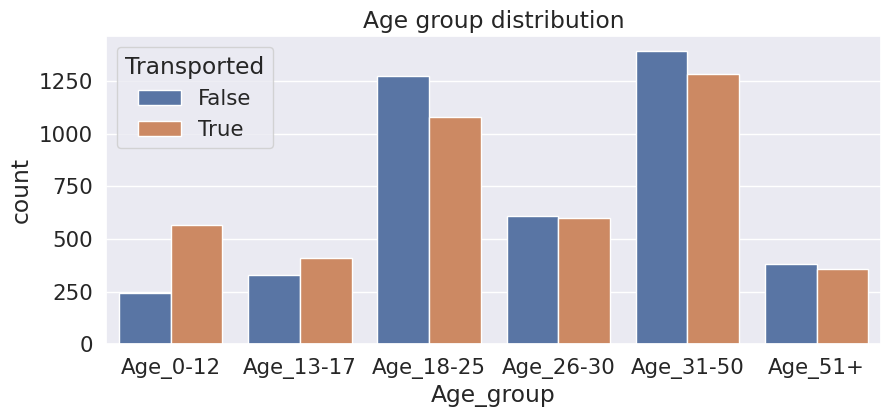

In [ ]:
# New features - training set
train['Age_group']=np.nan
train.loc[train['Age']<=12,'Age_group']='Age_0-12'
train.loc[(train['Age']>12) & (train['Age']<18),'Age_group']='Age_13-17'
train.loc[(train['Age']>=18) & (train['Age']<=25),'Age_group']='Age_18-25'
train.loc[(train['Age']>25) & (train['Age']<=30),'Age_group']='Age_26-30'
train.loc[(train['Age']>30) & (train['Age']<=50),'Age_group']='Age_31-50'
train.loc[train['Age']>50,'Age_group']='Age_51+'

# New features - test set
test['Age_group']=np.nan
test.loc[test['Age']<=12,'Age_group']='Age_0-12'
test.loc[(test['Age']>12) & (test['Age']<18),'Age_group']='Age_13-17'
test.loc[(test['Age']>=18) & (test['Age']<=25),'Age_group']='Age_18-25'
test.loc[(test['Age']>25) & (test['Age']<=30),'Age_group']='Age_26-30'
test.loc[(test['Age']>30) & (test['Age']<=50),'Age_group']='Age_31-50'
test.loc[test['Age']>50,'Age_group']='Age_51+'

# Plot distribution of new features
plt.figure(figsize=(10,4))
g = sns.countplot(
    data=train,
    x='Age_group',
    hue='Transported',
    order=['Age_0-12', 'Age_13-17', 'Age_18-25', 'Age_26-30', 'Age_31-50', 'Age_51+']
)
plt.title('Age group distribution')

<bound method Figure.tight_layout of <Figure size 1200x400 with 2 Axes>>

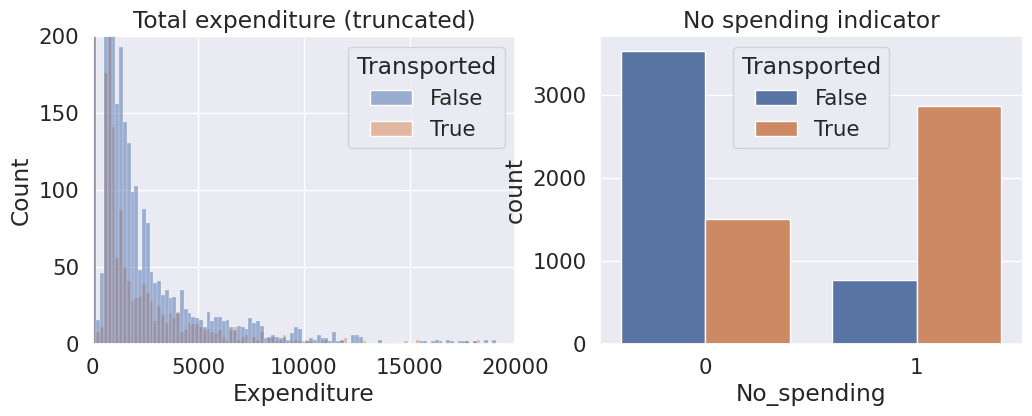

In [ ]:
# New features - training set
train['Expenditure'] = train[exp_feats].sum(axis=1)
train['No_spending'] = (train['Expenditure']==0).astype(int)

# New features - test set
test['Expenditure'] = test[exp_feats].sum(axis=1)
test['No_spending'] = (test['Expenditure']==0).astype(int)

fig = plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(
    data=train,
    x='Expenditure',
    hue='Transported',
    bins=200
)
plt.title('Total expenditure (truncated)')
plt.ylim([0,200])
plt.xlim([0, 20000])

plt.subplot(1,2,2)
sns.countplot(
    data=train,
    x='No_spending',
    hue='Transported'
)
plt.title('No spending indicator')
fig.tight_layout

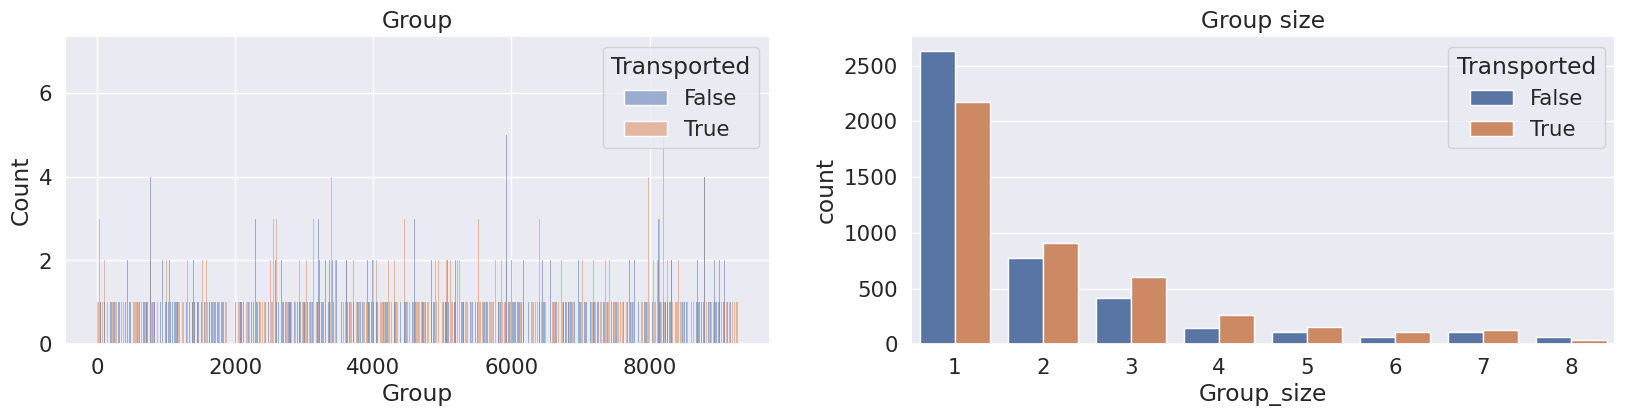

In [ ]:
# New feature - Group
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)

# New feature - Group size
train['Group_size'] = train['Group'].map(lambda x: pd.concat([train['Group'], test['Group']]).value_counts()[x])
test['Group_size'] = test['Group'].map(lambda x: pd.concat([train['Group'], test['Group']]).value_counts()[x])


# ------------------------------------------------------------------------------

# apply()
# ・任意の関数を行・列単位に適用できる柔軟なメソッド
# ・DataFrameとSeries両方で使える
# ・Seriesの場合は.map()と似ているが、もっと複雑な処理にも対応
# ・柔軟だが処理がやや重い

# map()
# ・Series専用のメソッド
# ・「各要素に関数 or 辞書 or Seriesを対応させる」処理に特化
# ・単純な置換や対応表による変換に向いている

# ------------------------------------------------------------------------------

plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
sns.histplot(
    data=train,
    x='Group',
    hue='Transported',
    binwidth=1
)
plt.title('Group')

plt.subplot(1,2,2)
sns.countplot(
    data=train,
    x='Group_size',
    hue='Transported'
)
plt.title('Group size')
fig.tight_layout()

(0.0, 3000.0)

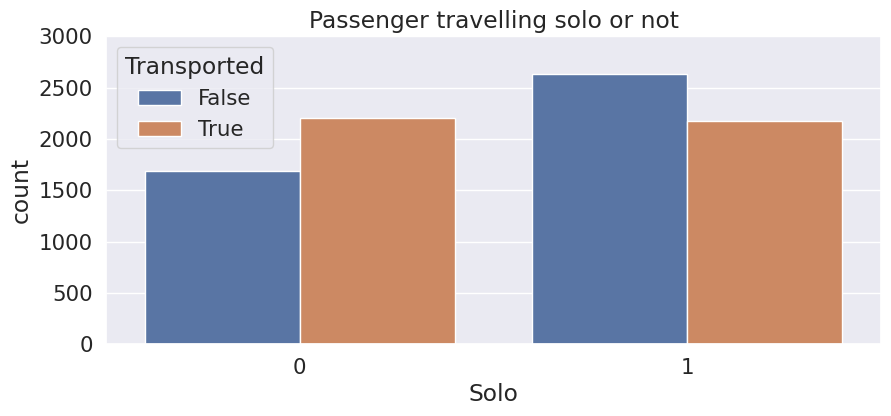

In [ ]:
# New feature
train['Solo'] = (train['Group_size']==1).astype(int)
test['Solo'] = (test['Group_size']==1).astype(int)

plt.figure(figsize=(10,4))
sns.countplot(
    data=train,
    x='Solo',
    hue='Transported'
)
plt.title('Passenger travelling solo or not')
plt.ylim([0, 3000])

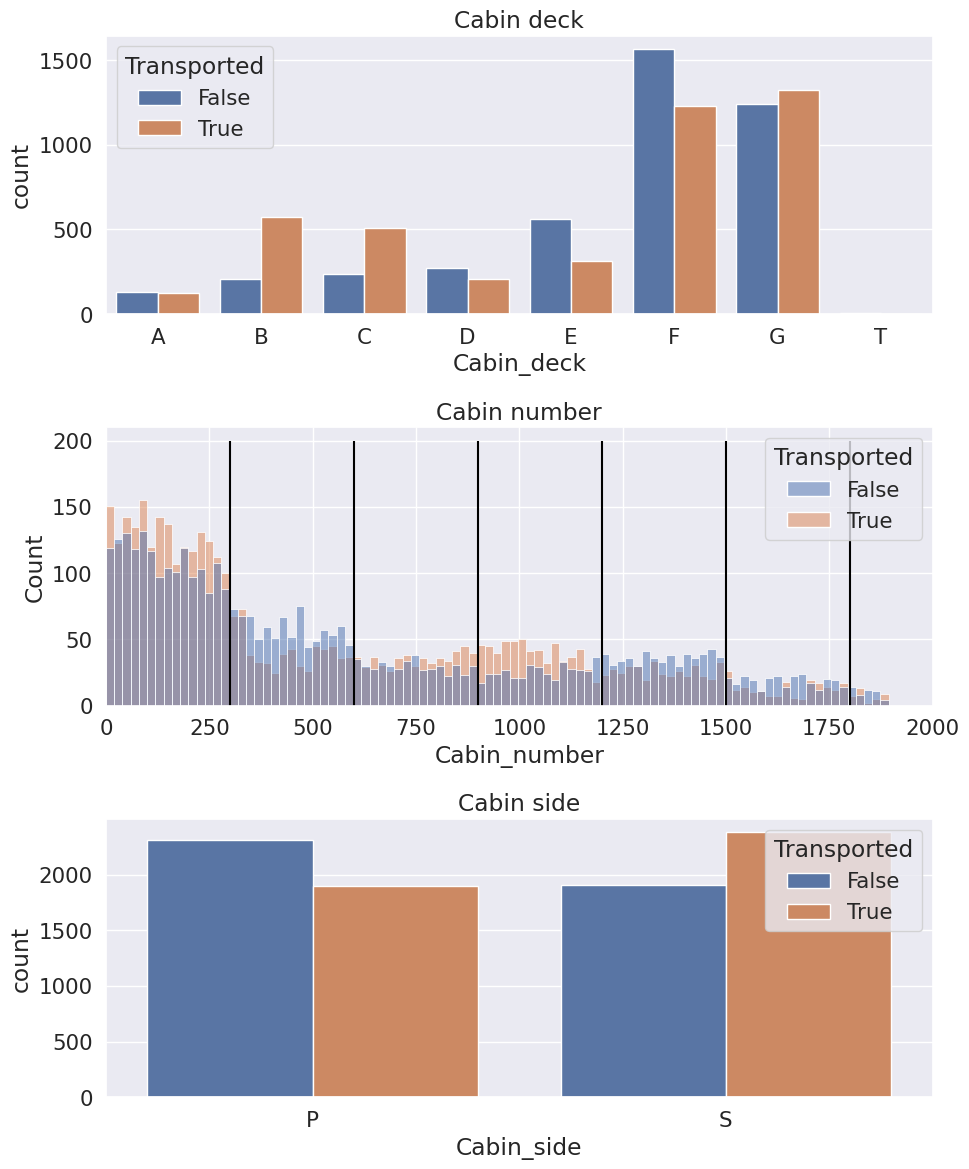

In [ ]:
# Replace NaN's with outliers for now (so we can split feature)
train['Cabin'].fillna('Z/9999/Z', inplace=True)
test['Cabin'].fillna('Z/9999/Z', inplace=True)

# New features - training set
train['Cabin_deck'] = train['Cabin'].apply(lambda x: x.split('/')[0])
train['Cabin_number'] = train['Cabin'].apply(lambda x: x.split('/')[1]).astype(int)
train['Cabin_side'] = train['Cabin'].apply(lambda x: x.split('/')[2])

# New features - test set
test['Cabin_deck'] = test['Cabin'].apply(lambda x: x.split('/')[0])
test['Cabin_number'] = test['Cabin'].apply(lambda x: x.split('/')[1]).astype(int)
test['Cabin_side'] = test['Cabin'].apply(lambda x: x.split('/')[2])

# Put Nan's back in (we will fill these later)
train.loc[train['Cabin_deck']=='Z', 'Cabin_deck']=np.nan
train.loc[train['Cabin_number']==9999, 'Cabin_number']=np.nan
train.loc[train['Cabin_side']=='Z', 'Cabin_side']=np.nan
test.loc[test['Cabin_deck']=='Z', 'Cabin_deck']=np.nan
test.loc[test['Cabin_number']==9999, 'Cabin_number']=np.nan
test.loc[test['Cabin_side']=='Z', 'Cabin_side']=np.nan

# Drop Cabin (we don't need it anymore)
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

# Plot distribution of new features
fig=plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
sns.countplot(data=train, x='Cabin_deck', hue='Transported', order=['A','B','C','D','E','F','G','T'])
plt.title('Cabin deck')

plt.subplot(3,1,2)
sns.histplot(data=train, x='Cabin_number', hue='Transported',binwidth=20)
# plt.vlines() : vertical linesの略で、縦線を描く関数
# ・plt.vlines(x, ymin, ymax, color=...)
# 　・x : 縦線を引く X座標
# 　・ymin : 縦線の下端のY座標
# 　・ymax : 縦線の上端のY座標
# 　・color : 線の色
plt.vlines(300, ymin=0, ymax=200, color='black')
plt.vlines(600, ymin=0, ymax=200, color='black')
plt.vlines(900, ymin=0, ymax=200, color='black')
plt.vlines(1200, ymin=0, ymax=200, color='black')
plt.vlines(1500, ymin=0, ymax=200, color='black')
plt.vlines(1800, ymin=0, ymax=200, color='black')
plt.title('Cabin number')
plt.xlim([0,2000])

plt.subplot(3,1,3)
sns.countplot(data=train, x='Cabin_side', hue='Transported')
plt.title('Cabin side')
fig.tight_layout()

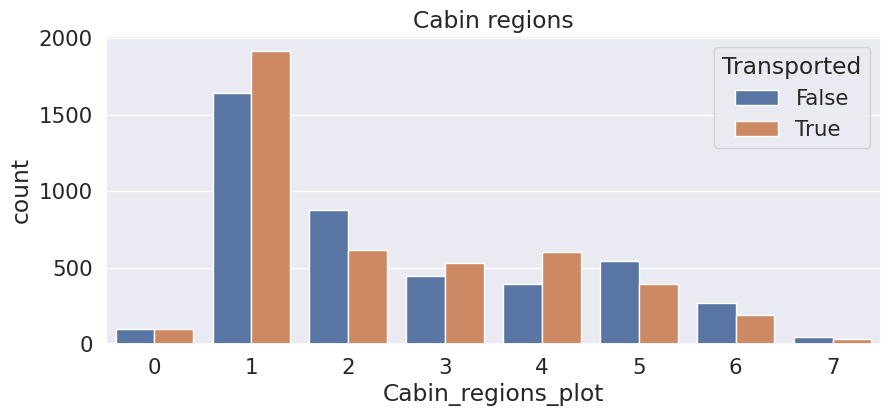

In [ ]:
# New features - training set
train['Cabin_region1']=(train['Cabin_number']<300).astype(int)   # one-hot encoding
train['Cabin_region2']=((train['Cabin_number']>=300) & (train['Cabin_number']<600)).astype(int)
train['Cabin_region3']=((train['Cabin_number']>=600) & (train['Cabin_number']<900)).astype(int)
train['Cabin_region4']=((train['Cabin_number']>=900) & (train['Cabin_number']<1200)).astype(int)
train['Cabin_region5']=((train['Cabin_number']>=1200) & (train['Cabin_number']<1500)).astype(int)
train['Cabin_region6']=((train['Cabin_number']>=1500) & (train['Cabin_number']<1800)).astype(int)
train['Cabin_region7']=(train['Cabin_number']>=1800).astype(int)

# New features - test set
test['Cabin_region1']=(test['Cabin_number']<300).astype(int)   # one-hot encoding
test['Cabin_region2']=((test['Cabin_number']>=300) & (test['Cabin_number']<600)).astype(int)
test['Cabin_region3']=((test['Cabin_number']>=600) & (test['Cabin_number']<900)).astype(int)
test['Cabin_region4']=((test['Cabin_number']>=900) & (test['Cabin_number']<1200)).astype(int)
test['Cabin_region5']=((test['Cabin_number']>=1200) & (test['Cabin_number']<1500)).astype(int)
test['Cabin_region6']=((test['Cabin_number']>=1500) & (test['Cabin_number']<1800)).astype(int)
test['Cabin_region7']=(test['Cabin_number']>=1800).astype(int)


plt.figure(figsize=(10,4))
# 各リージョンを「1〜7」の数値に変換するため(Cabin_region はonehot)
train['Cabin_regions_plot']=(
    train['Cabin_region1']
    +2*train['Cabin_region2']
    +3*train['Cabin_region3']
    +4*train['Cabin_region4']
    +5*train['Cabin_region5']
    +6*train['Cabin_region6']
    +7*train['Cabin_region7']
    ).astype(int)
sns.countplot(data=train, x='Cabin_regions_plot', hue='Transported')
plt.title('Cabin regions')
train.drop('Cabin_regions_plot', axis=1, inplace=True)

Text(0.5, 1.0, 'Family size')

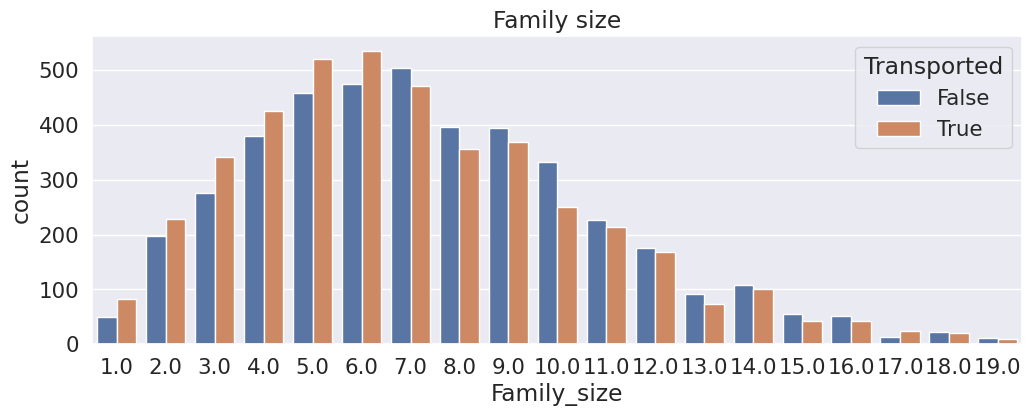

In [ ]:
# Replace NaN's with outliers for now (so we can split feature)
train['Name'].fillna('Unknown Unknown', inplace=True)
test['Name'].fillna('Unknown Unknown', inplace=True)

# New feature - Surname(苗字)
train['Surname']=train['Name'].str.split().str[-1]
test['Surname']=test['Name'].str.split().str[-1]

# New feature - Family size
train['Family_size']=train['Surname'].map(lambda x: pd.concat([train['Surname'],test['Surname']]).value_counts()[x])
test['Family_size']=test['Surname'].map(lambda x: pd.concat([train['Surname'],test['Surname']]).value_counts()[x])

# Put Nan's back in (we will fill these later)
train.loc[train['Surname']=='Unknown','Surname']=np.nan
train.loc[train['Family_size']>100,'Family_size']=np.nan
test.loc[test['Surname']=='Unknown','Surname']=np.nan
test.loc[test['Family_size']>100,'Family_size']=np.nan

# Drop name (we don't need it anymore)
train.drop('Name', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)


plt.figure(figsize=(12,4))
sns.countplot(
    data=train,
    x='Family_size',
    hue='Transported'
)
plt.title('Family size')

In [ ]:
# Missing values

y = train['Transported'].copy().astype(int)
X = train.drop('Transported', axis=1).copy()

data = pd.concat([X, test], axis=0).reset_index(drop=True)  # drop=True で古いインデックスを残さない

In [ ]:
# Columns with missing values
na_cols=data.columns[data.isna().any()].tolist()

# Missing values summary
mv=pd.DataFrame(data[na_cols].isna().sum(), columns=['Number_missing'])
mv['Percentage_missing']=np.round(100*mv['Number_missing']/len(data),2)
mv

,Number_missing,Percentage_missing
HomePlanet,288,2.22
CryoSleep,310,2.39
Destination,274,2.11
Age,270,2.08
VIP,296,2.28
RoomService,263,2.03
FoodCourt,289,2.23
ShoppingMall,306,2.36
Spa,284,2.19
VRDeck,268,2.07


Text(0.5, 1.0, 'Heatmap of missing values')

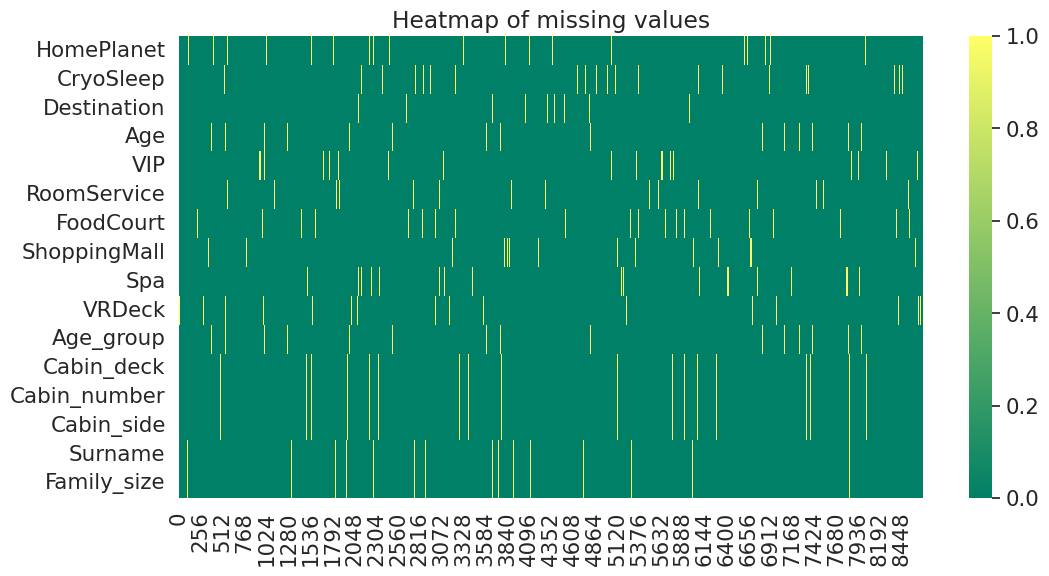

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(train[na_cols].isnull().T, cmap='summer')
plt.title('Heatmap of missing values')

# このヒートマップは どの特徴量に欠損があるか・どのくらい分布しているか を直感的に見せている。
# 縦の黄色 → 特徴量ごとの欠損率
# 横の黄色のかたまり → サンプル単位での欠損パターン

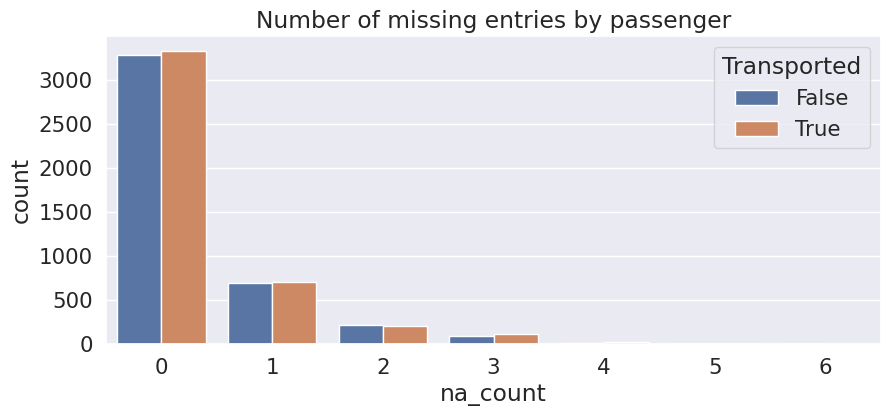

In [ ]:
train['na_count'] = train.isnull().sum(axis=1)
plt.figure(figsize=(10,4))
sns.countplot(
    data=train,
    x='na_count',
    hue='Transported'
)
plt.title('Number of missing entries by passenger')
train.drop('na_count', axis=1, inplace=True)

In [ ]:
# Group × HomePlanet のクロス集計表を作成
# 各グループ・惑星の組み合わせに対して 人数（件数）を数える

# Joint distribution of Group and HomePlanet
GHP_gb=data.groupby(['Group','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
GHP_gb.head()

HomePlanet,Earth,Europa,Mars
Group,,,
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,2.0,0.0
4,1.0,0.0,0.0
5,1.0,0.0,0.0


Text(0.5, 1.0, 'Number of unique home planets per group')

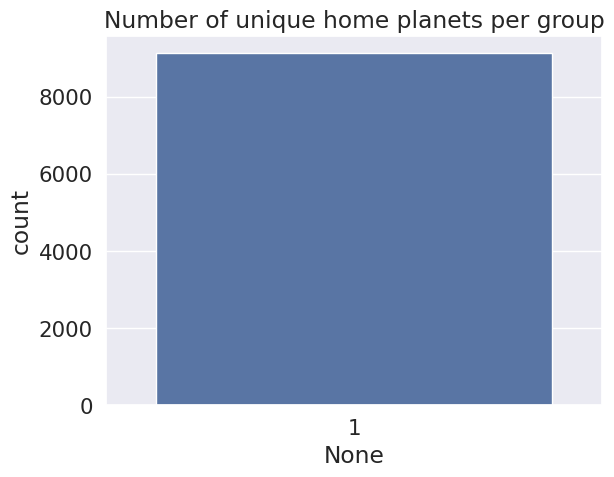

In [ ]:
# Countplot of unique values
sns.countplot(x=(GHP_gb>0).sum(axis=1))
plt.title('Number of unique home planets per group')

In [ ]:
# Missing values before
HP_bef=data['HomePlanet'].isna().sum()

# Passengers with missing HomePlanet and in a group with known HomePlanet
# 「HomePlanet が欠損しているけど、同じグループに HomePlanet が分かっている人がいる」行のインデックス
#  ・data['HomePlanet'].isna() → HomePlanet が欠損している行を抽出
#  ・その中で Group が GHP_gb に存在する（つまり他のメンバーがいる） 行を絞り込む
#  ・.index でその行番号（インデックス）を取得
GHP_index=data[data['HomePlanet'].isna()][(data[data['HomePlanet'].isna()]['Group']).isin(GHP_gb.index)].index

# Fill corresponding missing values
# .idxmax(axis=1) で「各グループで人数が最も多い HomePlanet」を返す
data.loc[GHP_index,'HomePlanet']=data.iloc[GHP_index,:]['Group'].map(lambda x: GHP_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 288
#HomePlanet missing values after: 157


<Axes: xlabel='Cabin_deck', ylabel='HomePlanet'>

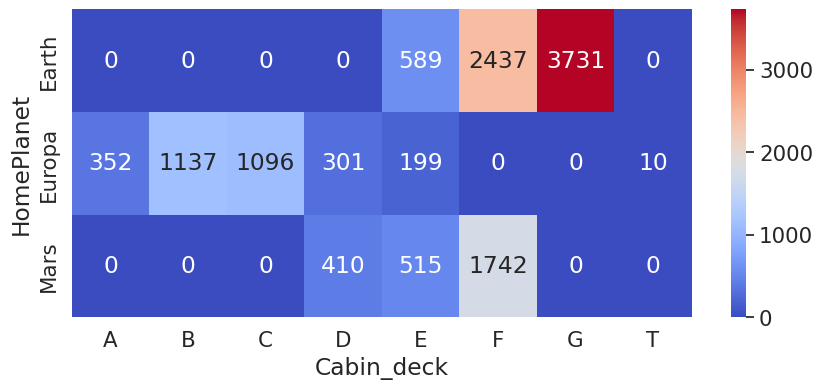

In [ ]:
# Joint distribution of CabinDeck and HomePlanet
CDHP_gb=data.groupby(['Cabin_deck','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)

# Heatmap of missing values
plt.figure(figsize=(10,4))
sns.heatmap(CDHP_gb.T, annot=True, fmt='g', cmap='coolwarm')

In [ ]:
# Missing values before
HP_bef=data['HomePlanet'].isna().sum()

# Decks A, B, C or T came from Europa
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck'].isin(['A', 'B', 'C', 'T'])), 'HomePlanet']='Europa'

# Deck G came from Earth
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck']=='G'), 'HomePlanet']='Earth'

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())


#HomePlanet missing values before: 157
#HomePlanet missing values after: 94


Text(0.5, 1.0, 'Number of unique planets per surname')

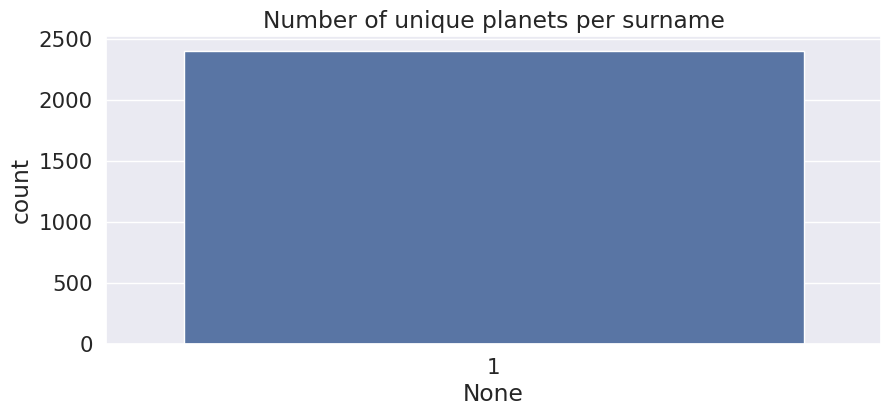

In [ ]:
# Joint distribution of Surname and HomePlanet
SHP_gb=data.groupby(['Surname','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)

# Countplot of unique values
plt.figure(figsize=(10,4))
sns.countplot(x=(SHP_gb>0).sum(axis=1))
plt.title('Number of unique planets per surname')

In [ ]:
# Missing values before
HP_bef=data['HomePlanet'].isna().sum()

# Passengers with missing HomePlanet and in a family with known HomePlanet
SHP_index=data[data['HomePlanet'].isna()][(data[data['HomePlanet'].isna()]['Surname']).isin(SHP_gb.index)].index

# Fill corresponding missing values
data.loc[SHP_index,'HomePlanet']=data.iloc[SHP_index,:]['Surname'].map(lambda x: SHP_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 94
#HomePlanet missing values after: 10


In [ ]:
# Only 10 HomePlanet missing values left - let's look at them
data[data['HomePlanet'].isna()][['PassengerId','HomePlanet','Destination']]

,PassengerId,HomePlanet,Destination
2274,2443_01,NaN,TRAPPIST-1e
2631,2817_01,NaN,TRAPPIST-1e
3091,3331_01,NaN,TRAPPIST-1e
4548,4840_01,NaN,TRAPPIST-1e
5762,6108_01,NaN,TRAPPIST-1e
8969,0616_01,NaN,TRAPPIST-1e
10583,4052_01,NaN,TRAPPIST-1e
11913,7065_01,NaN,TRAPPIST-1e
12551,8435_01,NaN,TRAPPIST-1e
12725,8775_01,NaN,TRAPPIST-1e


<Axes: xlabel='HomePlanet', ylabel='Destination'>

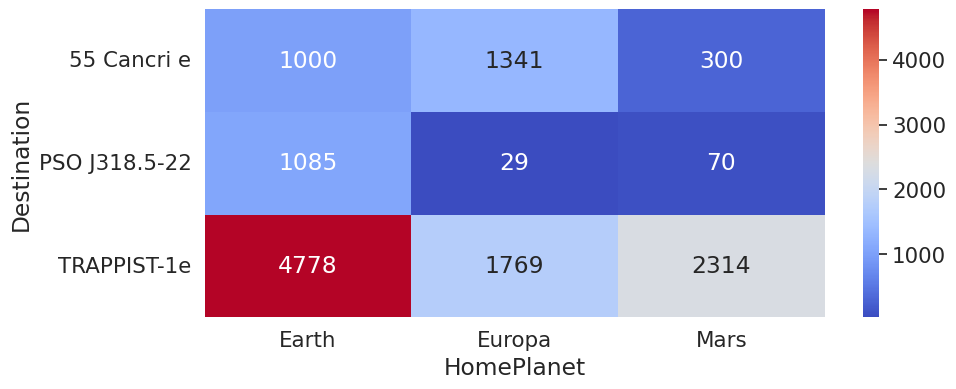

In [ ]:
# Joint distribution of HomePlanet and Destination
HPD_gb=data.groupby(['HomePlanet','Destination'])['Destination'].size().unstack().fillna(0)

# Heatmap of missing values
plt.figure(figsize=(10,4))
sns.heatmap(HPD_gb.T, annot=True, fmt='g', cmap='coolwarm')

In [ ]:
# Missing values before
HP_bef=data['HomePlanet'].isna().sum()

# Fill remaining HomePlanet missing values with Earth (if not on deck D) or Mars (if on Deck D)
data.loc[(data['HomePlanet'].isna()) & ~(data['Cabin_deck']=='D'), 'HomePlanet']='Earth'
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck']=='D'), 'HomePlanet']='Mars'

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 10
#HomePlanet missing values after: 0


In [ ]:
# Destination（降りる予定の惑星）の欠損値を、最頻値（mode = 一番多いカテゴリ）で埋めている処理

D_bef = data['Destination'].isnull().sum()

data.loc[(data['Destination'].isnull()), 'Destination'] = 'TRAPPIST-1e'

print('#Destination missing values before:',D_bef)
print('#Destination missing values after:',data['Destination'].isna().sum())

#Destination missing values before: 274
#Destination missing values after: 0


Text(0.5, 1.0, 'Number of unique surnames by group')

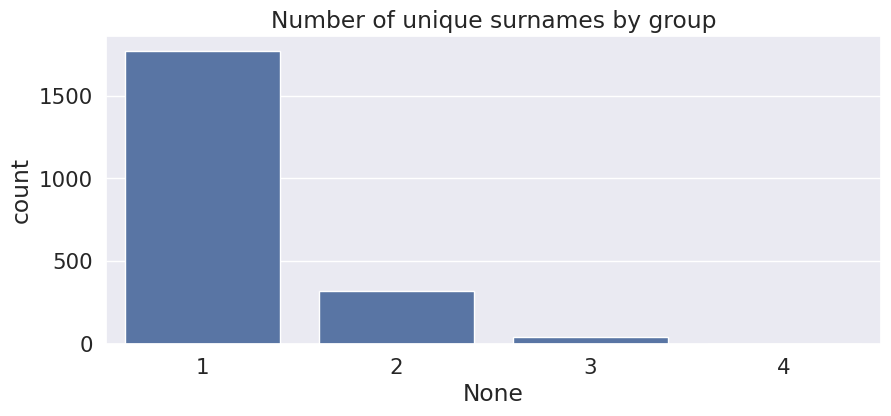

In [ ]:
# グループごとに苗字（Surname）がどのくらいの種類あるか」を集計・可視化

# Joint distribution of Group and Surname
GSN_gb=data[data['Group_size']>1].groupby(['Group','Surname'])['Surname'].size().unstack().fillna(0)

# Countplot of unique values
plt.figure(figsize=(10,4))
sns.countplot(x=(GSN_gb>0).sum(axis=1))
plt.title('Number of unique surnames by group')

In [ ]:
# 同じグループの“多数派の苗字（Surname）”で、欠損している Surname を補完する

SN_bef = data['Surname'].isnull().sum()

# 補完対象となる行（インデックス）を抽出
# ・data['Surname'].isna() で Surname が欠損の行を抽出
# ・その中から、Group が GSN_gb に存在するグループだけに絞る
# ・その行の インデックス（行番号） を GSN_index に入れる
GSN_index = data[data['Surname'].isna()][(data[data['Surname'].isna()]['Group']).isin(GSN_gb.index)].index

# GSN_gb は「Group × Surname の人数クロス表」
# .idxmax(axis=1) → 各グループごとに「人数が一番多い Surname」を返す
data.loc[GSN_index, 'Surname'] = data.iloc[GSN_index, :]['Group'].map(lambda x: GSN_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Surname missing values before:',SN_bef)
print('#Surname missing values after:',data['Surname'].isna().sum())

#Surname missing values before: 294
#Surname missing values after: 155


In [ ]:
data['Surname'].fillna('Unknown', inplace=True)

data['Family_size'] = data['Surname'].map(lambda x: data['Surname'].value_counts()[x])

data.loc[data['Surname'] == 'Unknown', 'Surname'] = np.nan

data.loc[data['Family_size']>100, 'Family_size'] = 0

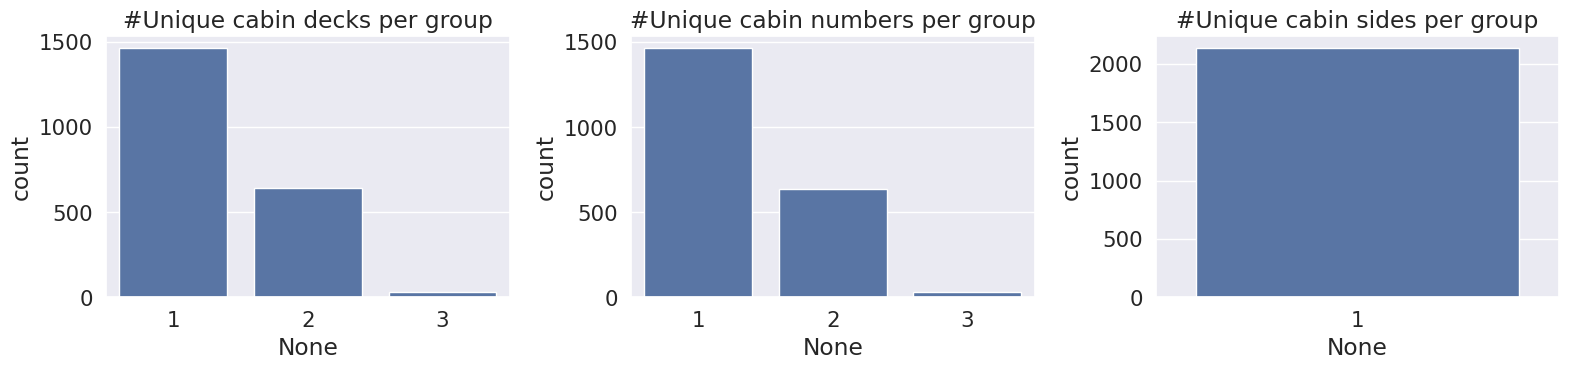

In [ ]:
# Group（同じ旅行グループ）と Cabin の各要素（Deck, Number, Side）の関係

GCD_gb = data[data['Group_size']>1].groupby(['Group', 'Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)
GCN_gb = data[data['Group_size']>1].groupby(['Group', 'Cabin_number'])['Cabin_number'].size().unstack().fillna(0)
GCS_gb = data[data['Group_size']>1].groupby(['Group', 'Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

fig = plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=(GCD_gb>0).sum(axis=1))
plt.title('#Unique cabin decks per group')

plt.subplot(1,3,2)
sns.countplot(x=(GCN_gb>0).sum(axis=1))
plt.title('#Unique cabin numbers per group')

plt.subplot(1,3,3)
sns.countplot(x=(GCS_gb>0).sum(axis=1))
plt.title('#Unique cabin sides per group')
fig.tight_layout()

In [ ]:
CS_bef = data['Cabin_side'].isnull().sum()

GCS_index=data[data['Cabin_side'].isna()][(data[data['Cabin_side'].isna()]['Group']).isin(GCS_gb.index)].index

data.loc[GCS_index, 'Cabin_side'] = data.iloc[GCS_index, :]['Group'].map(lambda x: GCS_gb.idxmax(axis=1)[x])

print('#Cabin_side missing values before:',CS_bef)
print('#Cabin_side missing values after:',data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 299
#Cabin_side missing values after: 162


Text(0.5, 1.0, 'Ratio of cabin side by surname')

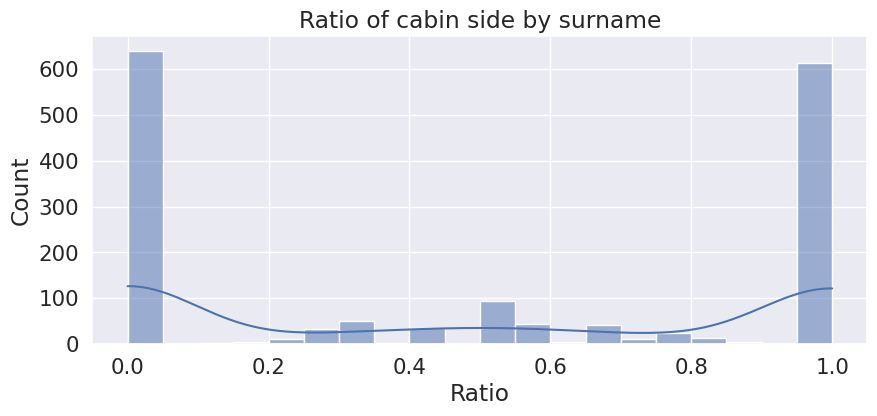

In [ ]:
# 同じ苗字（Surname）の人たちが、Cabin_side（船の左右：Port=左舷 / Starboard=右舷）のどちらに偏っているかを調べて、その比率分布を可視化

SCS_gb = data[data['Group_size']>1].groupby(['Surname','Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

SCS_gb['Ratio'] = SCS_gb['P'] / (SCS_gb['S'] + SCS_gb['P'])

plt.figure(figsize=(10,4))
sns.histplot(
    SCS_gb['Ratio'],
    kde=True,
    binwidth=0.05)
plt.title('Ratio of cabin side by surname')

# countplot = カテゴリ変数の出現回数を可視化する
# histplot = 数値変数（連続値）の分布を可視化する

In [ ]:
# 「苗字ごとの家族が全員同じCabin_side（左舷 or 右舷）にいた割合」を計算して表示

print('Percentage of families all on the same cabin side:',
      100*np.round((SCS_gb['Ratio'].isin([0,1])).sum()/len(SCS_gb),3),'%')

SCS_gb.head()

Percentage of families all on the same cabin side: 76.7 %


Cabin_side,P,S,Ratio
Surname,,,
Acobson,0.0,3.0,0.0
Acobsond,3.0,0.0,1.0
Adavisons,6.0,0.0,1.0
Admingried,0.0,4.0,0.0
Aginge,3.0,0.0,1.0


In [ ]:
# Missing values before
CS_bef=data['Cabin_side'].isna().sum()

# Drop ratio column
SCS_gb.drop('Ratio', axis=1, inplace=True)

# Passengers with missing Cabin side and in a family with known Cabin side
SCS_index=data[data['Cabin_side'].isna()][(data[data['Cabin_side'].isna()]['Surname']).isin(SCS_gb.index)].index

# Fill corresponding missing values
data.loc[SCS_index,'Cabin_side']=data.iloc[SCS_index,:]['Surname'].map(lambda x: SCS_gb.idxmax(axis=1)[x])

# Drop surname (we don't need it anymore)
data.drop('Surname', axis=1, inplace=True)

# Print number of missing values left
print('#Cabin_side missing values before:',CS_bef)
print('#Cabin_side missing values after:',data['Cabin_side'].isna().sum())
print('#Cabin_side missing values after:',data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 162
#Cabin_side missing values after: 66
#Cabin_side missing values after: 66


In [ ]:
# Value counts
data['Cabin_side'].value_counts()

,count
Cabin_side,
S,6504
P,6400


In [ ]:
# Missing values before
CS_bef=data['Cabin_side'].isna().sum()

# Fill remaining missing values with outlier
data.loc[data['Cabin_side'].isna(),'Cabin_side']='Z'

# Print number of missing values left
print('#Cabin_side missing values before:',CS_bef)
print('#Cabin_side missing values after:',data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 66
#Cabin_side missing values after: 0


In [ ]:
# Missing values before
CD_bef=data['Cabin_deck'].isna().sum()

# Passengers with missing Cabin deck and in a group with known majority Cabin deck
GCD_index=data[data['Cabin_deck'].isna()][(data[data['Cabin_deck'].isna()]['Group']).isin(GCD_gb.index)].index

# Fill corresponding missing values
data.loc[GCD_index,'Cabin_deck']=data.iloc[GCD_index,:]['Group'].map(lambda x: GCD_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Cabin_deck missing values before:',CD_bef)
print('#Cabin_deck missing values after:',data['Cabin_deck'].isna().sum())

#Cabin_deck missing values before: 299
#Cabin_deck missing values after: 162


In [ ]:
data.groupby(['HomePlanet','Destination','Solo','Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)

Cabin_deck                         A      B      C      D      E       F  \
HomePlanet Destination   Solo                                              
Earth      55 Cancri e   0       0.0    0.0    0.0    0.0   20.0    90.0   
                         1       0.0    0.0    0.0    0.0   47.0   289.0   
           PSO J318.5-22 0       0.0    0.0    0.0    0.0   18.0    67.0   
                         1       0.0    0.0    0.0    0.0   25.0   262.0   
           TRAPPIST-1e   0       0.0    0.0    0.0    0.0  133.0   438.0   
                         1       0.0    0.0    0.0    0.0  358.0  1350.0   
Europa     55 Cancri e   0      96.0  377.0  313.0   59.0   35.0     0.0   
                         1      67.0  141.0  159.0   46.0   34.0     0.0   
           PSO J318.5-22 0       2.0    5.0   11.0    0.0    0.0     0.0   
                         1       0.0    0.0   10.0    0.0    0.0     0.0   
           TRAPPIST-1e   0     152.0  459.0  428.0  120.0   53.0     0.0   
                         1      44.0  179.0  201.0   84.0   82.0     0.0   
Mars       55 Cancri e   0       0.0    0.0    0.0   32.0   15.0   104.0   
                         1       0.0    0.0    0.0   40.0   16.0    92.0   
           PSO J318.5-22 0       0.0    0.0    0.0    8.0    9.0    14.0   
                         1       0.0    0.0    0.0    9.0    7.0    21.0   
           TRAPPIST-1e   0       0.0    0.0    0.0  168.0  219.0   798.0   
                         1       0.0    0.0    0.0  164.0  263.0   743.0   

Cabin_deck                          G    T  
HomePlanet Destination   Solo               
Earth      55 Cancri e   0      272.0  0.0  
                         1      269.0  0.0  
           PSO J318.5-22 0      230.0  0.0  
                         1      466.0  0.0  
           TRAPPIST-1e   0     1075.0  0.0  
                         1     1509.0  0.0  
Europa     55 Cancri e   0        0.0  2.0  
                         1        0.0  0.0  
           PSO J318.5-22 0        0.0  0.0  
                         1        0.0  0.0  
           TRAPPIST-1e   0        0.0  1.0  
                         1        0.0  8.0  
Mars       55 Cancri e   0        0.0  0.0  
                         1        0.0  0.0  
           PSO J318.5-22 0        0.0  0.0  
                         1        0.0  0.0  
           TRAPPIST-1e   0        0.0  0.0  
                         1        0.0  0.0

In [ ]:
# Missing values before
CD_bef=data['Cabin_deck'].isna().sum()

# Fill missing values using the mode
na_rows_CD=data.loc[data['Cabin_deck'].isna(),'Cabin_deck'].index
data.loc[data['Cabin_deck'].isna(),'Cabin_deck']=data.groupby(['HomePlanet','Destination','Solo'])['Cabin_deck'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CD]

# Print number of missing values left
print('#Cabin_deck missing values before:',CD_bef)
print('#Cabin_deck missing values after:',data['Cabin_deck'].isna().sum())

#Cabin_deck missing values before: 162
#Cabin_deck missing values after: 0


Text(0.5, 1.0, 'Cabin_number vs group colored by group')

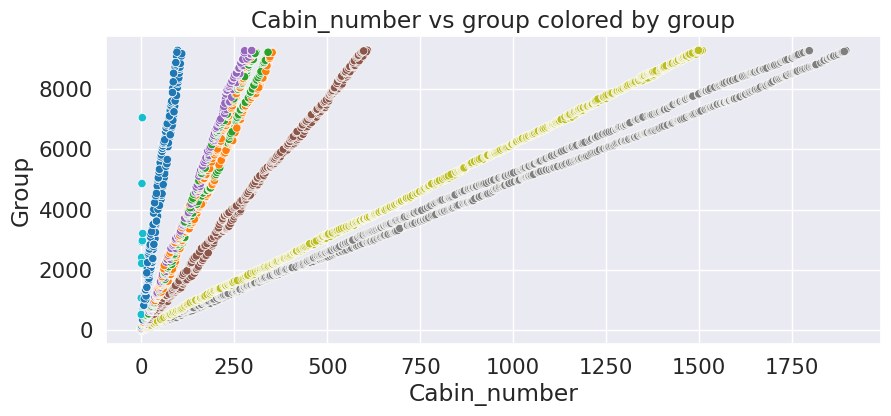

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(
    x=data['Cabin_number'],
    y=data['Group'],
    c=LabelEncoder().fit_transform(data.loc[~data['Cabin_number'].isnull(), 'Cabin_deck']),
    cmap='tab10'
)
plt.title('Cabin_number vs group colored by group')

In [ ]:
# Missing values before
CN_bef=data['Cabin_number'].isna().sum()

# Extrapolate linear relationship on a deck by deck basis
for deck in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    # Features and labels
    X_CN=data.loc[~(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Group']
    y_CN=data.loc[~(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Cabin_number']
    X_test_CN=data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Group']

    # Linear regression
    model_CN=LinearRegression()
    model_CN.fit(X_CN.values.reshape(-1, 1), y_CN)
    preds_CN=model_CN.predict(X_test_CN.values.reshape(-1, 1))

    # Fill missing values with predictions
    data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck']==deck),'Cabin_number']=preds_CN.astype(int)

# Print number of missing values left
print('#Cabin_number missing values before:',CN_bef)
print('#Cabin_number missing values after:',data['Cabin_number'].isna().sum())

#Cabin_number missing values before: 299
#Cabin_number missing values after: 0


In [ ]:
# One-hot encode cabin regions
data['Cabin_region1']=(data['Cabin_number']<300).astype(int)
data['Cabin_region2']=((data['Cabin_number']>=300) & (data['Cabin_number']<600)).astype(int)
data['Cabin_region3']=((data['Cabin_number']>=600) & (data['Cabin_number']<900)).astype(int)
data['Cabin_region4']=((data['Cabin_number']>=900) & (data['Cabin_number']<1200)).astype(int)
data['Cabin_region5']=((data['Cabin_number']>=1200) & (data['Cabin_number']<1500)).astype(int)
data['Cabin_region6']=((data['Cabin_number']>=1500) & (data['Cabin_number']<1800)).astype(int)
data['Cabin_region7']=(data['Cabin_number']>=1800).astype(int)

In [ ]:
data['VIP'].value_counts()

,count
VIP,
False,12401
True,273


In [ ]:
V_bef = data['VIP'].isnull().sum()
data.loc[data['VIP'].isnull(), 'VIP'] = False
print('#VIP missing values before : ', V_bef)
print('#VIP missing values after : ', data['VIP'].isnull().sum())

#VIP missing values before :  296
#VIP missing values after :  0


In [ ]:
data.groupby(['HomePlanet','No_spending','Solo','Cabin_deck'])['Age'].median().unstack().fillna(0)

Cabin_deck                      A     B     C     D     E     F     G     T
HomePlanet No_spending Solo                                                
Earth      0           0      0.0   0.0   0.0   0.0  24.0  25.0  28.0   0.0
                       1      0.0   0.0   0.0   0.0  25.0  24.0  26.0   0.0
           1           0      0.0   0.0   0.0   0.0   7.0  16.0   8.0   0.0
                       1      0.0   0.0   0.0   0.0  21.0  21.5  23.0   0.0
Europa     0           0     35.0  34.0  33.0  33.0  34.0   0.0   0.0  44.0
                       1     35.0  36.0  35.5  34.0  35.0   0.0   0.0  35.0
           1           0     30.0  27.0  28.5  27.0  28.0   0.0   0.0   0.0
                       1     37.5  34.0  35.0  31.0  33.0   0.0   0.0   0.0
Mars       0           0      0.0   0.0   0.0  30.0  29.0  29.0   0.0   0.0
                       1      0.0   0.0   0.0  31.0  28.5  30.0   0.0   0.0
           1           0      0.0   0.0   0.0  29.5  26.0  18.0   0.0   0.0
                       1      0.0   0.0   0.0  33.0  30.0  29.5   0.0   0.0

In [ ]:
# Missing values before
A_bef=data[exp_feats].isna().sum().sum()
# HomePlanet, No_spending, Solo, Cabin_deck の 組み合わせごとに Age を見て、
# そのグループの 中央値で NaN を埋めたシリーズを transform で作成します。
# Fill missing values using the median
na_rows_A=data.loc[data['Age'].isna(),'Age'].index
data.loc[data['Age'].isna(),'Age']=data.groupby(['HomePlanet','No_spending','Solo','Cabin_deck'])['Age'].transform(lambda x: x.fillna(x.median()))[na_rows_A]

# Print number of missing values left
print('#Age missing values before:',A_bef)
print('#Age missing values after:',data['Age'].isna().sum())

#Age missing values before: 1410
#Age missing values after: 0


In [ ]:
# Update age group feature
data.loc[data['Age']<=12,'Age_group']='Age_0-12'
data.loc[(data['Age']>12) & (data['Age']<18),'Age_group']='Age_13-17'
data.loc[(data['Age']>=18) & (data['Age']<=25),'Age_group']='Age_18-25'
data.loc[(data['Age']>25) & (data['Age']<=30),'Age_group']='Age_26-30'
data.loc[(data['Age']>30) & (data['Age']<=50),'Age_group']='Age_31-50'
data.loc[data['Age']>50,'Age_group']='Age_51+'

In [ ]:
data['Age'].isnull().sum()

np.int64(0)

In [ ]:
data.groupby(['No_spending', 'CryoSleep'])['CryoSleep'].size().unstack().fillna(0)

CryoSleep,False,True
No_spending,,
0,7339.0,0.0
1,740.0,4581.0


In [ ]:
CSL_bef = data['CryoSleep'].isnull().sum()

na_rows_CSL = data.loc[data['CryoSleep'].isnull(), 'CryoSleep'].index
data.loc[data['CryoSleep'].isnull(), 'CryoSleep'] = data.groupby(['No_spending'])['CryoSleep'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CSL]

In [ ]:
print('#CryoSleep missing values before:',CSL_bef)
print('#CryoSleep missing values after:',data['CryoSleep'].isna().sum())

#CryoSleep missing values before: 310
#CryoSleep missing values after: 0


In [ ]:
data.loc[data['CryoSleep']==True, exp_feats].sum(axis=1).max()

0.0

In [ ]:
print('Maximum expenditure of passengers in CryoSleep:',data.loc[data['CryoSleep']==True,exp_feats].sum(axis=1).max())

Maximum expenditure of passengers in CryoSleep: 0.0


In [ ]:
# Missing values before
E_bef=data[exp_feats].isna().sum().sum()

# CryoSleep has no expenditure
for col in exp_feats:
    data.loc[(data[col].isna()) & (data['CryoSleep']==True), col]=0

# Print number of missing values left
print('#Expenditure missing values before:',E_bef)
print('#Expenditure missing values after:',data[exp_feats].isna().sum().sum())

#Expenditure missing values before: 1410
#Expenditure missing values after: 866


In [ ]:
data.groupby(['HomePlanet', 'Solo', 'Age_group'])['Expenditure'].mean().unstack().fillna(0)

Age_group        Age_0-12    Age_13-17    Age_18-25    Age_26-30    Age_31-50  \
HomePlanet Solo                                                                 
Earth      0          0.0   724.902222   789.700555   841.093596   736.655773   
           1          0.0   693.014898   779.395942   795.420690   794.818627   
Europa     0          0.0  1153.160256  2652.013298  3534.668246  3975.774005   
           1          0.0     0.000000  2489.888889  3806.000000  3949.939929   
Mars       0          0.0  1176.839286  1161.808333  1247.098361  1143.671916   
           1          0.0  1687.261538  1075.341146  1107.122677  1110.392045   

Age_group            Age_51+  
HomePlanet Solo               
Earth      0      733.649573  
           1      826.366972  
Europa     0     3483.639004  
           1     3952.085526  
Mars       0     1345.419643  
           1     1100.298387

In [ ]:
E_bef = data[exp_feats].isnull().sum().sum()

for col in exp_feats:
  na_rows = data.loc[data[col].isnull(), col].index
  data.loc[data[col].isnull(), col] = data.groupby(['HomePlanet', 'Solo', 'Age_group'])[col].transform(lambda x: x.fillna(x.mean()))[na_rows]

print('#Expenditure missing values before:',E_bef)
print('#Expenditure missing values after:',data[exp_feats].isna().sum().sum())

#Expenditure missing values before: 866
#Expenditure missing values after: 0


In [ ]:
data['Expenditure']=data[exp_feats].sum(axis=1)
data['No_spending']=(data['Expenditure']==0).astype(int)

In [ ]:
data.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0


In [ ]:
# Train and test
X=data[data['PassengerId'].isin(train['PassengerId'].values)].copy()
X_test=data[data['PassengerId'].isin(test['PassengerId'].values)].copy()

In [ ]:
# Drop qualitative/redundant/collinear/high cardinality features
X.drop(['PassengerId', 'Group', 'Group_size', 'Age_group', 'Cabin_number'], axis=1, inplace=True)
X_test.drop(['PassengerId', 'Group', 'Group_size', 'Age_group', 'Cabin_number'], axis=1, inplace=True)

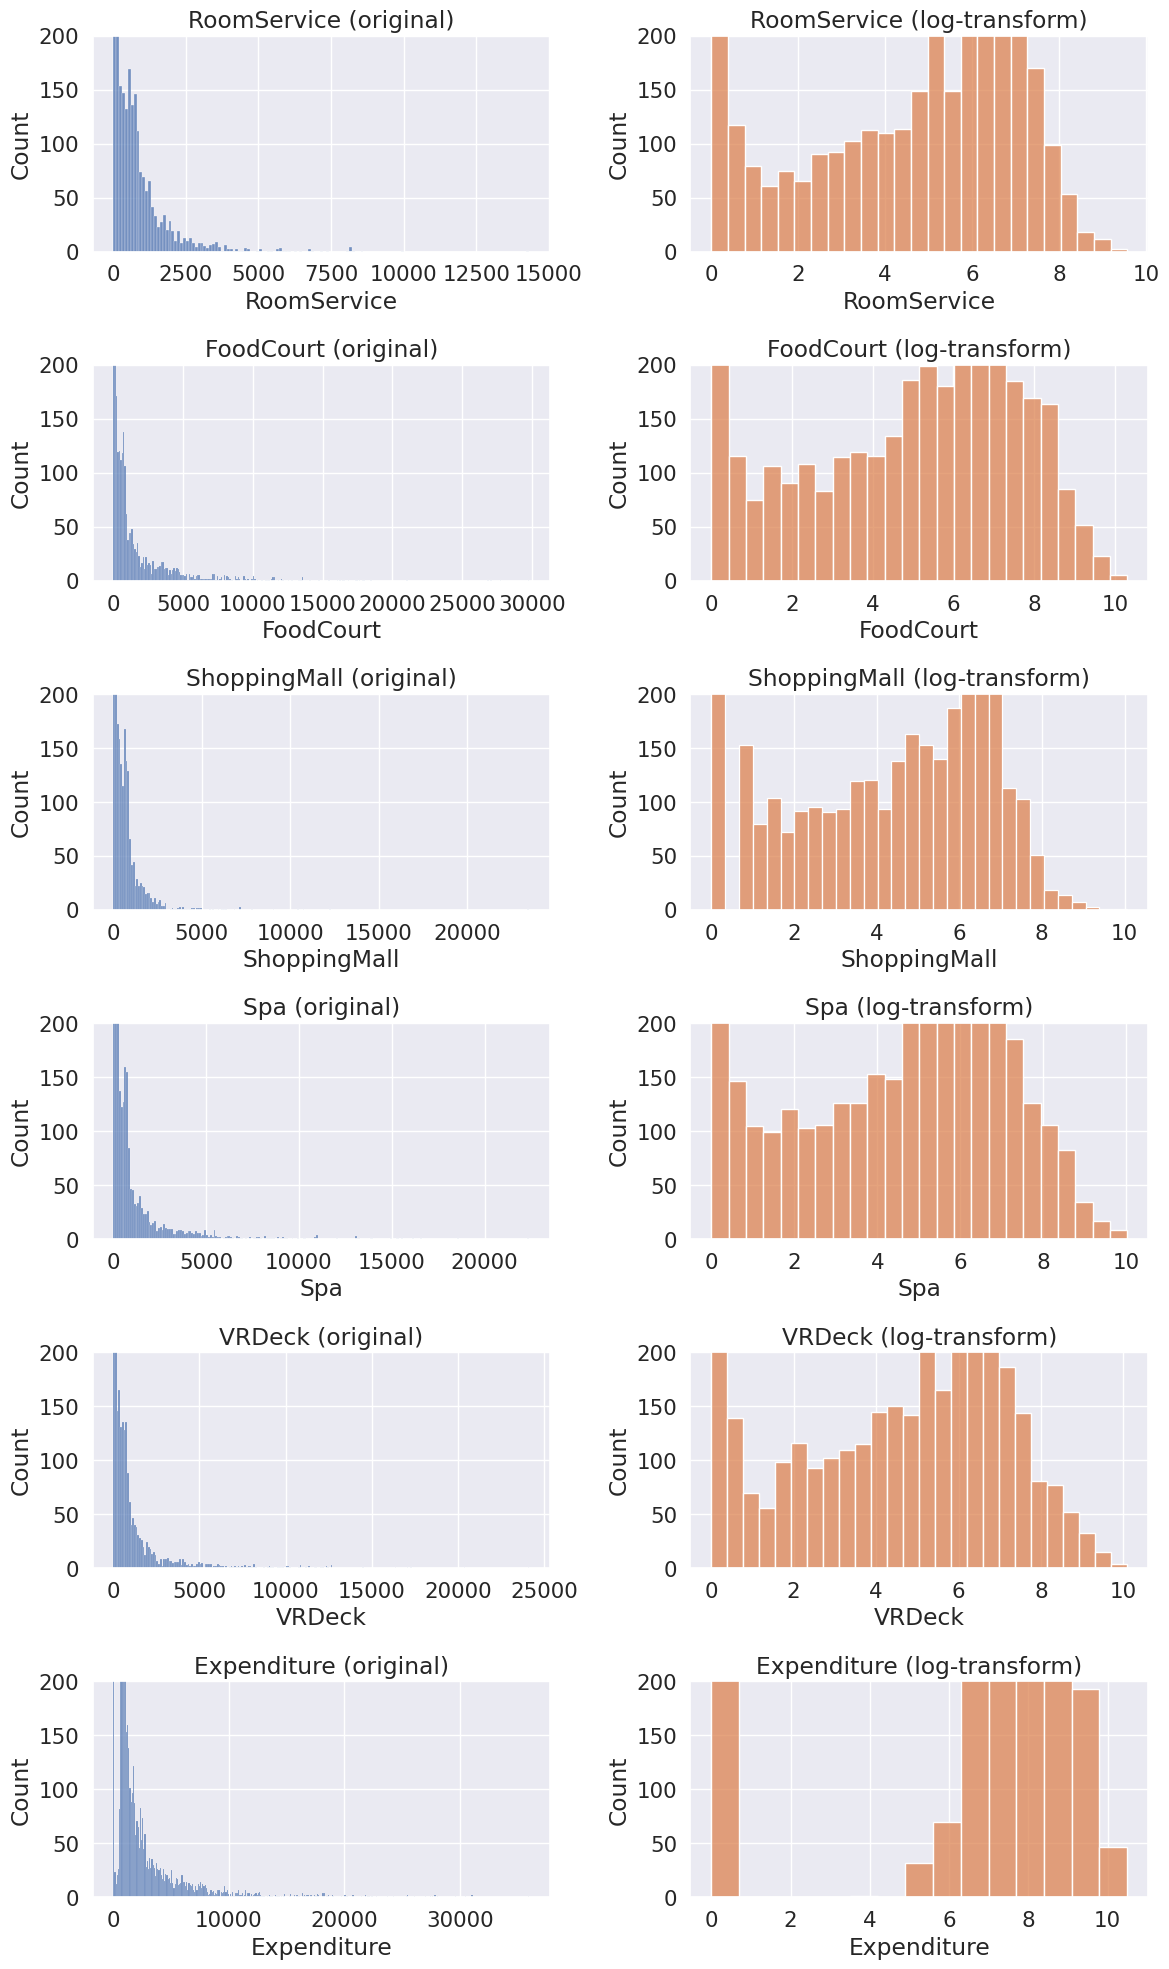

In [ ]:
fig = plt.figure(figsize=(12,20))
for i, col in enumerate(['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']):
  plt.subplot(6, 2,2*i+1)
  sns.histplot(X[col], binwidth=100)
  plt.ylim([0,200])
  plt.title(f'{col} (original)')

  plt.subplot(6,2,2*i+2)
  sns.histplot(np.log1p(X[col]), color='C1')
  plt.ylim([0,200])
  plt.title(f'{col} (log-transform)')

fig.tight_layout()
plt.show()

In [ ]:
for col in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']:
    X[col]=np.log(1+X[col])
    X_test[col]=np.log(1+X_test[col])

In [ ]:
# Indentify numerical and categorical columns
numerical_cols = [cname for cname in X.columns if X[cname].dtype in ['int64', 'float64']]
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]

# Scale numerical data to have mean=0 and variance=1
numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# drop : 多重共線性の対策のため、１列わざと削除するオプション
# ・drop=None : 全てのカテゴリをそのまま使う（デフォルト）
# → 木系モデルで使用（木系モデルでは列の冗長性が気にならないため）
# ・drop='first' : 各カテゴリの最初の列を削除
# → 線形モデルで多重共線性を防ぐ
# ・drop='if_binary' : ２値カテゴリのみ１列にする（１列目を削除）
# → 一般的なバランス型設定

# handle_unknown : 道カテゴリが来た時の扱い。学習時にA,Bしか見ていないのに、テストでCが出てきた時にどうするかを決める引数
# ・handle_unknown='error' : 未知カテゴリがあるとエラーで止まる（デフォルト）
# → データが完全に揃っているときに使う
# ・handle_unknown='ignore' : 未知カテゴリは「すべて０（どの列にも該当しない）にする」
# → 実務ではこの設定が多い

# sparse_output : 出力形式の指定。one-hotエンコード後は大奥の０ができる。これをどう保存するかを決める引数
# ・sparse_output=True : 疎行列を返す（デフォルト）
# → メモリ節約、軽い。一方表示・加工が少し面倒
# ・sparse_output=False : Numpy配列を返す
# → 扱いやすいが、メモリを多く消費する
# One-hot encode categorical data
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore',sparse_output=False))])

# Combine preprocessing
# ColumnTransformer : 列ごとに異なる前処理をまとめて行えるツール
# <基本構文>
#from sklearn.compose import ColumnTransformer

#ct = ColumnTransformer(
    #transformers=[
        #('名前1', 変換器1, 対象列リスト1),
        #('名前2', 変換器2, 対象列リスト2)
    #],
    #remainder='drop'  # または 'passthrough'
#)

# remainder : 指定されなかった列をどうするか
# ・remainder='drop' : 指定していない列は全て削除される（デフォルト）
# ・remainder='passthrough : そのまま残す
ct = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)],
        remainder='passthrough')

# Apply preprocessing
X = ct.fit_transform(X)
X_test = ct.transform(X_test)

# Print new shape
print('Training set shape:', X.shape)

Training set shape: (8693, 36)


In [ ]:
pca = PCA(n_components=3)
components = pca.fit_transform(X)

total_var = pca.explained_variance_ratio_.sum() * 100

#
fig = px.scatter_3d(
    components, x=0, y=1, z=2, color=y, size=0.1*np.ones(len(X)), opacity = 1,
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'},
    width=800, height=500
)
fig.show()

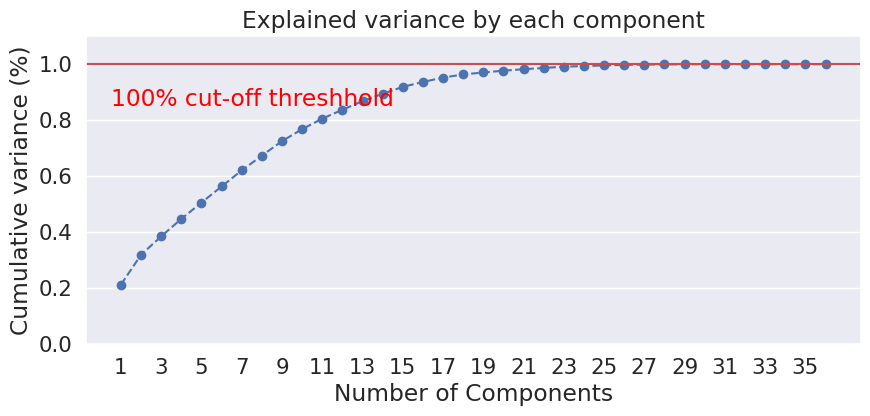

In [ ]:
pca = PCA().fit(X)
# PCA().fit(X : PCAモデルを学習するだけ。以下の属性がpcaオブジェクトに保存される。
# pca.components_	各主成分の方向ベクトル（固有ベクトル）
# pca.explained_variance_	各主成分の分散（固有値）
# pca.explained_variance_ratio_	各主成分が説明する分散の割合
# pca.mean_	各特徴量の平均（中心化に使う）
# 戻り値 : None

# PCA().fit_transform(X) : 学習して、すぐに「変換」もする
# 戻り値 : 主成分スコア（次元削減後のデータ）

# PCA().fit(X).components_ : 出力は主成分分析後の軸ベクトル
# PCA().fit_transform() =
# X_pca=PCA().fit(X)
# X_pca.tansform(X)
# → これで線型写像後の値が得られる（shapeは（サンプル, n_components））
fig, ax = plt.subplots(figsize=(10,4))
xi = np.arange(1, 1+X.shape[1], step=1)
yi = np.cumsum(pca.explained_variance_ratio_)
plt.plot(xi, yi, marker='o', linestyle='--', color='b')

plt.ylim(0.0, 1.1)
plt.xlabel('Number of Components')
# plt.xticks() : x軸のメモリ（ticks）を自由に設定するための関数
# ・目盛を指定する	     : plt.xticks([0, 5, 10])	x軸に 0,5,10 だけ表示
# ・ラベルを文字に変える	: plt.xticks([0,1,2], ['A','B','C'])	x軸に A, B, C と表示
# ・ラベルを回転する	   : plt.xticks(rotation=90)	ラベルを縦に表示（あなたの使い方）
# ・目盛を間引く	      :  plt.xticks(np.arange(1, 11, 2))	1,3,5,7,9 のみ表示
plt.xticks(np.arange(1, 1+X.shape[1], step=2))
plt.ylabel('Cumulative variance (%)')
plt.title('Explained variance by each component')
plt.axhline(y=1, color='r', linestyle='-')
plt.text(0.5, 0.85, '100% cut-off threshhold', color='red')
ax.grid(axis='x')

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, stratify=y, train_size=0.8, test_size=0.2, random_state=0)
# stratify : 分類問題でデータ分割するときにクラスの比率を保つためのもの
# stratify=y → 目的変数yのクラス分布（割合）をtrainとtestの両方で同じに保つという指定
# → もしstratifyを指定しないと分割は完全にランダムになる。
# → その結果、特にクラスが偏っているデータでは偏りがそれぞれのデータセットで生じ、学習・評価のバランスが崩れて正しいモデル性能が測れない

In [ ]:
# Model selection
classifiers = {
    'LogisticRegression' : LogisticRegression(random_state=0),
    'KNN' : KNeighborsClassifier(),
    'SVC' : SVC(random_state=0, probability=True),
    'RandomForest' : RandomForestClassifier(random_state=0),
    #'XGboost' : XGBClassifier(random_state=0, use_label_encoder=False, eval_metoric='logloss),
    'LGBM' : LGBMClassifier(random_state=0),
    'CatBoost' : CatBoostClassifier(random_state=0, verbose=0),
    'NaiveBayes' : GaussianNB()
}

# grid(グリッド) : ハイパーパラメータの候補を整理した一覧
# Grids for grid search
LR_grid = {'penalty': ['l1','l2'],
           'C': [0.25, 0.5, 0.75, 1, 1.25, 1.5],
           'max_iter': [50, 100, 150]}

KNN_grid = {'n_neighbors': [3, 5, 7, 9],
            'p': [1, 2]}

SVC_grid = {'C': [0.25, 0.5, 0.75, 1, 1.25, 1.5],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']}

RF_grid = {'n_estimators': [50, 100, 150, 200, 250, 300],
        'max_depth': [4, 6, 8, 10, 12]}

boosted_grid = {'n_estimators': [50, 100, 150, 200],
        'max_depth': [4, 8, 12],
        'learning_rate': [0.05, 0.1, 0.15]}

NB_grid={'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7]}

# Dictionary of all grids
grid = {
    "LogisticRegression" : LR_grid,
    "KNN" : KNN_grid,
    "SVC" : SVC_grid,
    "RandomForest" : RF_grid,
    "XGBoost" : boosted_grid,
    "LGBM" : boosted_grid,
    "CatBoost" : boosted_grid,
    "NaiveBayes": NB_grid
}

In [ ]:
# 回帰モデル

"""
<ロジスティック回帰>

LogisticRegression(
    penalty = 'l2'          # 正則化の種類 l1,l2,elasticnet,none
    C = 1.0                 # 正則化強度の逆数 値を小さくすると正則化が強くなる
    max_iter = 100          # 反復回数の上限
    random_state = None     # 乱数シード
)

・正則化項について：
C = 1 / λ
→ Cが小さいほどL2ペナルティが強くなる
→ Cが小さいほどL1ペナルティが強くなる
→ Cが小さいほどペナルティが強くなり、l1_ratio=でL1,L2ノルムの強さを指定する

・max_iterについて：
ロジスティック回帰の学習では、重みの更新を繰り返し行い、目的関数（損失関数）がほぼ変化しなくなるまで繰り返す
→この繰り返し回数の上限をmax_iterで設定する
→ロジスティック回帰の目的関数（尤度）は非線形であり、解析的に解を求めることができない（重回帰分析は解析的に最小二乗法で最適な重みを計算できる）
→そのため、勾配効果法などの反復最適化が必要になる

"""

"""
<k近傍法>

KNeighborsClassifier(
  n_neighbors=5              # 近傍点の数 k
  weights='uniform'          # 投票の重み付け方法
  p=2                        # 距離の指数
  metric='minkowski'         # 距離の種類
)

・KNNとは：
学習データにおける近い点を参考にしてクラスを決める（多数決）
→ fitの時はtrainデータを記憶するでけで、パラメータの学習などはしない
→ preedictの時にtrainデータにtestデータを入れて、各testデータ点の周囲のtrainデータのクラスに基づいて多数決を行う
→ この時一つのtestデータは他すべてのtrainデータとの距離を測り、上位k個のtrainデータで多数決を行う
→ kをn_neightborsで指定
→ 距離はpとmetricsで指定

・metricsについて
metricsはminkowskiがデフォルト（パラメータpがある）
→ ・p=1の時 : マンハッタン距離
→ ・p=2の時 : ユークリッド距離
→ metrics=minkowskiの時のみpを参照
→ metricsが他のものに設定されているときはpは無視される

"""

"""
<SVM>

SVM(
  C=1.0             # 正則化パラメータ（誤分類をどこまで許すか）
  kernel='rbf'      # カーネル関数（非線形分離を可能にする）
  gamma='scale'     # カーネルの広がりを決める
  degree=3          # kernel='poly'の場合の多項式次数
  probability=False # Trueにすると」,predict_proba()が使える
  random_state=None # 乱数シード
)

・SVMとは：
データをできるだけ広いマージンで分ける境界線を探すアルゴリズム
→クラウスかんのマージンを最大化する超平面を探す
→線形SVMなら、直線（または平面）でクラスを分離
→非線形SVMなら、カーネル関数で特徴空間を拡張し、線形的に分離

・Cについて：
Cは正則化パラメータ（誤分類をどこまで許すか）
→ ・Cが小さい：広いマージンをとって全体をなめらかに分ける
→ ・Cが大きい：訓練データにピッタリ沿うように分ける
→Cが大きいとハードマージン寄り、Cが小さいとソフトマージン寄りになる。（理論的にはCが無限大の時ハードマージン、有限であれば全てソフトマージン）
→実務的には「C≲1」なら明確にソフト、「C≫10」でハードマージンに近づく

・kernelについて：
→非線形分離に使う
　・linear : 直線/平面 →ロジスティック回帰に近い。高速
　・poly : 多項式曲線　→　degreeで柔軟性を調整
　・rbf : 放射規定（ガウス）
　・sigmoid : 双曲線的

・gammaについて：
rbfカーネルやpolyカーネルに影響するパラメータ
・scale :
→データの分散を使ってgammaを自動的に調整
→特徴量のスケールが大きくても、それを考慮して適度な広がりにする
→より堅牢で、標準化を前提とした設定と相性がいい
→原稿のデフォルトかつ推奨
・auto :
→特徴量のスケール（値の大きさ）を考慮しない
→特徴量の分散が大きい場合でもgammaが小さくなりすぎない
→結果的にやや鋭い（局所的）な境界になることが多い
→つまり、スケーリングしていない生データでは挙動が不安定

"""

"""
<ランダムフォレスト>
たくさんの決定木を組み合わせて分類や回帰を行うアンサンブル学習モデル
→ データと特徴量をランダムに分け、複数の木で多数決
・学習
→trainデータをブートストラップでランダムに分割し、複数の訓練用サブセットを作る
→各サブセットで決定木を学習させる
→普通の決定木と違い、ランダムフォレストでは、分岐のたびに使う特徴量もランダムに選ぶ
→すべての特徴量を使わず、ランダムに選んだ一部だけで分岐を決める
→これにより、各木の多様性が生まれ、過学習しにくくなる
→予測は、各決定木にtestデータを入力し、各木が独自にクラスを予測する
→さ初子に全木の出力で多数決（分類）もしくは平均（回帰）

RandomForestClassifier(
  n_estimators=100          # 決定木の本数
  max_depth=None            # 各決定木の深さを制限（深いほど複雑で過学習しやすい）
  random_state=None         # 乱数シード
)
"""

"""
<LightGBM(LGBMClassifier)>

・勾配ブースティングのアルゴリズム
一つ目の木で出力した結果と正解データの誤差（勾配）を計算し、
次の木はその勾配を目的変数として学習を行う。

一本目の出力＋二本目の木の出力×αと正解データの間の勾配を求め、
それを三本目の目的変数として三本目の学習を行う。

これを繰り返して学習を進める。


LGBNClassifier(
  n_estimator=100        # 木の本数：ブースティングの繰り返し回数（多いほど精度高だが、過学習の可能性あり。learning_rateとセットで調整）
  learning_rate=0.1      # 学習率：各木が前の誤差をどれだけ修正するか（小さいほど丁寧だが時間増。0.05~0.1が定番）
  max_depth=-1           # 木の最大の深さ：制限なし（-1）だと深くなりすぎることがある。過学習気味なら5~15に制限
  random_state=None      # 乱数シード
)
"""

"""
<CatBoost>
・CatBoostClassifier は、Yandex（ロシアの検索エンジン会社）が開発した
・勾配ブースティング法（Gradient Boosting） に基づく分類器
・カテゴリ変数（文字やラベル型）を自動的に扱える のが最大の特徴(One-hotやLabel Encoding不要)
・勾配ブースティング（GBDT）ベース
・高精度かつ過学習しにくい
→カテゴリ変数を自動で扱え、過学習を防ぐ安定型ブースティングモデル


CatBoostClassifier(
  n_estimator=100        # 木の本数：ブースティングの繰り返し回数（多いほど精度高だが、過学習の可能性あり。learning_rateとセットで調整）
  learning_rate=0.1      # 学習率：各木が前の誤差をどれだけ修正するか（小さいほど丁寧だが時間増。0.05~0.1が定番）
  max_depth=-1           # 木の最大の深さ：制限なし（-1）だと深くなりすぎることがある。過学習気味なら5~15に制限
  random_state=None      # 乱数シード
)
"""

"""
<ナイーブベイズ分類器>
「各クラスの特徴が正規分布に従う」と仮定して、
ベイズの定理に基づき確率的に分類を行うモデル

GaussianNB(
  var_smoothing=1e-9
)

非常に軽量・高速で、ベースラインモデルとして優秀。
パラメータもシンプルで、「まずこれでざっくり分類性能を確かめる」用途に最適。
"""

'\n<ナイーブベイズ分類器>\n「各クラスの特徴が正規分布に従う」と仮定して、\nベイズの定理に基づき確率的に分類を行うモデル\n\nGaussianNB(\n  var_smoothing=1e-9\n)\n\n非常に軽量・高速で、ベースラインモデルとして優秀。\nパラメータもシンプルで、「まずこれでざっくり分類性能を確かめる」用途に最適。\n'

In [ ]:
i = 0
clf_best_params = classifiers.copy()
valid_scores = pd.DataFrame({'Classifier':classifiers.keys(), 'Validation accuracy':np.zeros(len(classifiers)),'Training time':np.zeros(len(classifiers))})
for key, classifier in classifiers.items():
  start = time.time()
  clf = GridSearchCV(estimator=classifier, param_grid=grid[key], n_jobs=-1, cv=None)

  clf.fit(X_train, y_train)
  valid_scores.iloc[i, 1] = clf.score(X_valid, y_valid)

  clf_best_params[key] = clf.best_params_

  stop = time.time()
  valid_scores.iloc[i, 2] = np.round((stop - start) / 60, 2)

  print('Model:', key)
  print('Training time (mins):', valid_scores.iloc[i, 2])
  print('')
  i+= 1

Model: LogisticRegression
Training time (mins): 0.08

Model: KNN
Training time (mins): 0.09

Model: SVC
Training time (mins): 11.29

Model: RandomForest
Training time (mins): 1.71

[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1696
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503595 -> initscore=0.014380
[LightGBM] [Info] Start training from score 0.014380
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

In [ ]:
valid_scores

,Classifier,Validation accuracy,Training time
0,LogisticRegression,0.770558,0.08
1,KNN,0.745831,0.09
2,SVC,0.791834,11.29
3,RandomForest,0.790684,1.71
4,LGBM,0.797585,0.47
5,CatBoost,0.807361,13.16
6,NaiveBayes,0.719954,0.00


In [ ]:
clf_best_params

{'LogisticRegression': {'C': 0.5, 'max_iter': 50, 'penalty': 'l2'},
 'KNN': {'n_neighbors': 9, 'p': 2},
 'SVC': {'C': 1.25, 'gamma': 'scale', 'kernel': 'rbf'},
 'RandomForest': {'max_depth': 10, 'n_estimators': 250},
 'LGBM': {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100},
 'CatBoost': {'learning_rate': 0.15, 'max_depth': 4, 'n_estimators': 100},
 'NaiveBayes': {'var_smoothing': 1e-07}}

In [ ]:
# Classifiers
best_classifiers = {
    "LGBM" : LGBMClassifier(**clf_best_params["LGBM"], random_state=0),
    "CatBoost" : CatBoostClassifier(**clf_best_params["CatBoost"], verbose=False, random_state=0),
}

In [ ]:
# Number of folds in cross validation
FOLDS=10

preds=np.zeros(len(X_test))
for key, classifier in best_classifiers.items():
    start = time.time()

    # 10-fold cross validation
    cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=0)

    score=0
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        # Get training and validation sets
        X_train, X_valid = X[train_idx], X[val_idx]
        y_train, y_valid = y[train_idx], y[val_idx]

        # Train model
        clf = classifier
        clf.fit(X_train, y_train)

        # Make predictions and measure accuracy
        preds += clf.predict_proba(X_test)[:,1]
        score += clf.score(X_valid, y_valid)

    # Average accuracy
    score=score/FOLDS

    # Stop timer
    stop = time.time()

    # Print accuracy and time
    print('Model:', key)
    print('Average validation accuracy:', np.round(100*score,2))
    print('Training time (mins):', np.round((stop - start)/60,2))
    print('')

# Ensemble predictions
preds=preds/(FOLDS*len(best_classifiers))

[LightGBM] [Info] Number of positive: 3940, number of negative: 3883
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001056 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1696
[LightGBM] [Info] Number of data points in the train set: 7823, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503643 -> initscore=0.014573
[LightGBM] [Info] Start training from score 0.014573
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 3940, number of negative: 3883
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1696
[LightGBM] [Info] Number of data points in 

Text(0.5, 0, 'Probability')

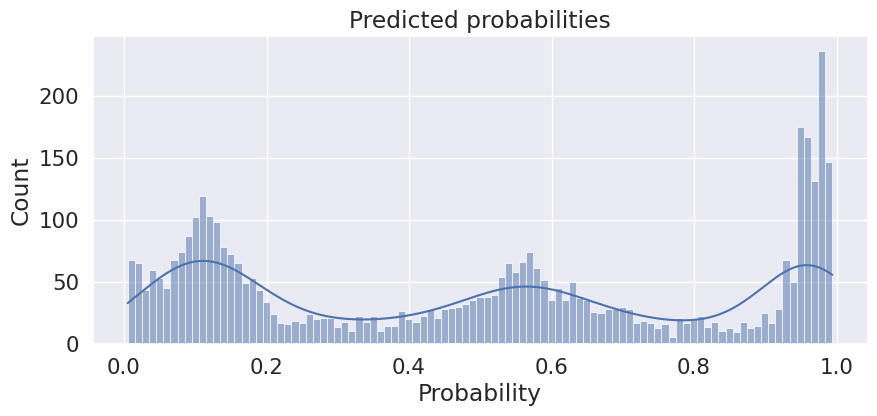

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(preds, binwidth=0.01, kde=True)
plt.title('Predicted probabilities')
plt.xlabel('Probability')

In [ ]:
# Proportion (in test set) we get from rounding
print(np.round(100*np.round(preds).sum()/len(preds),2))

52.84


Optimal threshold: 0.51


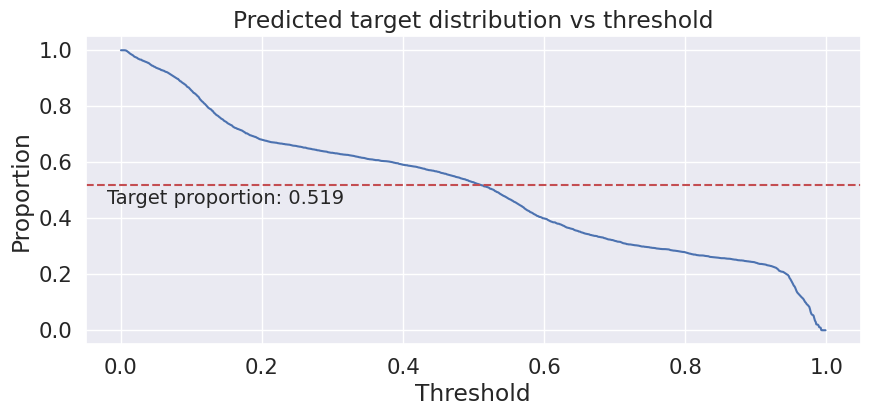

In [ ]:
# Proportion of predicted positive (transported) classes
def preds_prop(preds_arr, thresh):
    pred_classes=(preds_arr>=thresh).astype(int)
    return pred_classes.sum()/len(pred_classes)

# Plot proportions across a range of thresholds
def plot_preds_prop(preds_arr):
    # Array of thresholds
    T_array=np.arange(0,1,0.001)

    # Calculate proportions
    prop=np.zeros(len(T_array))
    for i, T in enumerate(T_array):
        prop[i]=preds_prop(preds_arr, T)

    # Plot proportions
    plt.figure(figsize=(10,4))
    plt.plot(T_array, prop)
    target_prop=0.519         # Experiment with this value
    plt.axhline(y=target_prop, color='r', linestyle='--')
    plt.text(-0.02,0.45,f'Target proportion: {target_prop}', fontsize=14)
    plt.title('Predicted target distribution vs threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Proportion')

    # Find optimal threshold (the one that leads to the proportion being closest to target_prop)
    T_opt=T_array[np.abs(prop-target_prop).argmin()]
    print('Optimal threshold:', T_opt)
    return T_opt

T_opt=plot_preds_prop(preds)

In [ ]:
# Classify test set using optimal threshold
preds_tuned=(preds>=T_opt).astype(int)

# Spaceship Titanic Competition End To End Project


https://www.kaggle.com/code/kdsharma/spaceship-titanic-competition-end-to-end-project

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
# Jupyter NotebookでMatplotlibを使ったグラフをノートブック上に直接表示するマジックコマンド
sns.set(style='darkgrid', font_scale=1.5)   # Seabornの全体的なスタイル設定を指定
pd.set_option('display.max.rows', None)     # PandasのDataFrameやSeriesで全ての行を省略せずに表示（Noneで制限解除）
pd.set_option('display.max.columns', None)  # PandasのDataFrameやSeriesで全ての列を省略せずに表示（Noneで制限解除）

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

from imblearn.over_sampling import SMOTE

In [3]:
url_train = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/spaceship-titanic/train.csv'
url_test = 'https://raw.githubusercontent.com/ky106031/kaggle-datasets/main/spaceship-titanic/test.csv'
train_df = pd.read_csv(url_train)
test_df = pd.read_csv(url_test)

In [4]:
print('Training Dataset shape is:', train_df.shape)
print('Test Dataset shape is:', test_df.shape)

Training Dataset shape is: (8693, 14)
Test Dataset shape is: (4277, 13)


In [5]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
test_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [7]:
print(f"Duplicates in Train Dataset is:{train_df.duplicated().sum()}, ({100*train_df.duplicated().sum()/len(train_df)}%)")
print(f"Duplicates in Test Dataset is:{test_df.duplicated().sum()},({100*test_df.duplicated().sum()/len(test_df)}%)")

Duplicates in Train Dataset is:0, (0.0%)
Duplicates in Test Dataset is:0,(0.0%)


In [8]:
print('Data Types of features of Training Data is :')
print(train_df.dtypes)
print('\n'+'-'*100)
print('\nData Types of features of Testing Data is:')
print(test_df.dtypes)

Data Types of features of Training Data is :
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

----------------------------------------------------------------------------------------------------

Data Types of features of Testing Data is:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
dtype: object


In [16]:
df1 = (train_df.isnull().sum()[train_df.isnull().sum()>0]).to_frame().rename(columns={0:'Number of Mising values'})
df1['% of Missing Values'] = round(100 * train_df.isnull().sum()[train_df.isnull().sum()>0]/len(train_df),2)
df1

,Number of Mising values,% of Missing Values
HomePlanet,201,2.31
CryoSleep,217,2.50
Cabin,199,2.29
Destination,182,2.09
Age,179,2.06
VIP,203,2.34
RoomService,181,2.08
FoodCourt,183,2.11
ShoppingMall,208,2.39
Spa,183,2.11


In [19]:
df2 = (test_df.isnull().sum()[test_df.isnull().sum()>0]).to_frame().rename(columns={0:'Number of Mising values'})
df2["% of Missing Values"] = round((100*test_df.isnull().sum()[test_df.isnull().sum()>0]/len(test_df)),2).values
df2

,Number of Mising values,% of Missing Values
HomePlanet,87,2.03
CryoSleep,93,2.17
Cabin,100,2.34
Destination,92,2.15
Age,91,2.13
VIP,93,2.17
RoomService,82,1.92
FoodCourt,106,2.48
ShoppingMall,98,2.29
Spa,101,2.36


In [21]:
# df.select_dtypes()
# →特定のデータ型を持つ列だけを取り出すメソッド
# df.select_dtypes(include=データ型)
#  ex: df.select_dtypes(include="object")
#      df.select_dtypes(include=["int", "float"])
# df.select_dtypes(exclude=データ型)

# df.nunique()
# →データのユニークな値の数を数えるメソッド
# df["column"].nunique()
print('cardinality of caftegorical features in training datasets is:')
print(train_df.select_dtypes(include='object').nunique())
print("\n",'-'*70)
print("\nCardinality fo categorical feaatures in testing datasets is:")
print(test_df.select_dtypes(include='object').nunique())

cardinality of caftegorical features in training datasets is:
PassengerId    8693
HomePlanet        3
CryoSleep         2
Cabin          6560
Destination       3
VIP               2
Name           8473
dtype: int64

 ----------------------------------------------------------------------

Cardinality fo categorical feaatures in testing datasets is:
PassengerId    4277
HomePlanet        3
CryoSleep         2
Cabin          3265
Destination       3
VIP               2
Name           4176
dtype: int64


Text(0.5, 1.0, 'Transported Feature Distribution')

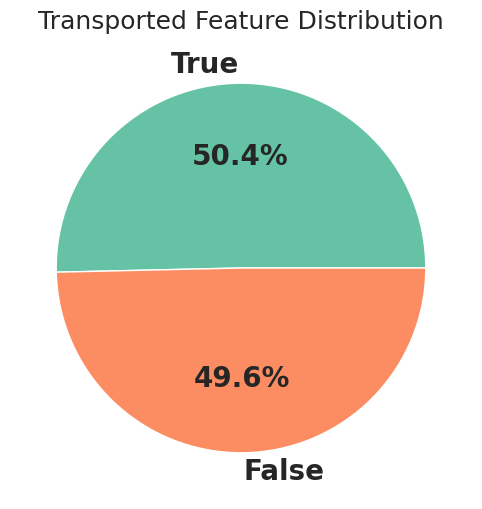

In [24]:
plt.figure(figsize=(10,6))
plt.pie(train_df['Transported'].value_counts(),
        labels=train_df['Transported'].value_counts().keys(),
        autopct='%1.1f%%',
        textprops={'fontsize':20, 'fontweight':'black'},
        colors=sns.color_palette('Set2'))
plt.title('Transported Feature Distribution')

Text(0.5, 1.0, 'Age Feature Distribution')

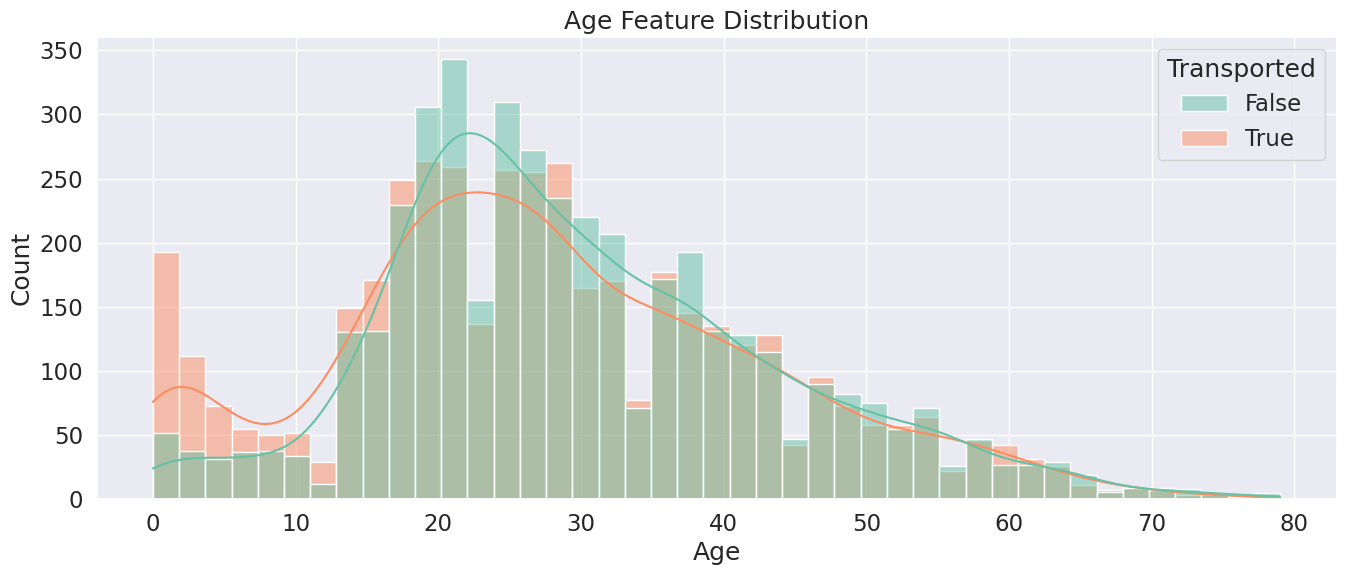

In [30]:
plt.figure(figsize=(16,6))
sns.histplot(x=train_df['Age'],
             hue='Transported',
             data=train_df,
             kde=True,
             palette='Set2')
plt.title('Age Feature Distribution')